# Phase 0 conclusion

`plan_benzon_implementation.md`'s own "Conclusion" section has the pass/fail-per-phase
narrative. This notebook is the full data write-up: every dataset used across
`notebooks_benzon/phase_0/` (1_commitment, 2_nuance, 3_synonyms, 4_list_elicitation,
5_twenty_questions), every observation method (OM) and ground truth (GT) grouped by
construct, and — the part that's actually executable rather than just reference tables — the
complete general OM x GT matrix. `1_commitment.ipynb`, `2_nuance.ipynb`, and
`3_synonyms.ipynb` each log every `(dataset, OM, GT)` cell they compute to a shared
`trial.json` (`vconf.trial_log`), but only `3_synonyms.ipynb` ran the *complete* general
9-OM x 6-GT cross product; `1_commitment.ipynb`/`2_nuance.ipynb` only tested each construct
against the ground truths it was originally built for (commitment vs. {answer logit, self
challenge resistance, labeled challenge resistance}, nuance vs. {binary entropy, nonbinary
logit}). This notebook reads `trial.json` back, finds every missing general cell on TriviaQA
and `benzon:ontology_trivials` (the two datasets with gaps), computes them for real, logs the
results, and plots the matrix complete — no missing cells left.

In [1]:
import json
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

HERE = pathlib.Path.cwd()
with open(HERE / "config.json") as f:
    MODEL_CONFIG = json.load(f)
MODEL_NAME = MODEL_CONFIG["model"]
os.environ["VCONF_MODEL"] = MODEL_NAME
CACHE_DIR = HERE / "cache" / MODEL_NAME
OUT_DIR = HERE / "out" / MODEL_NAME
FIGS_DIR = OUT_DIR / "figs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
TRIAL_LOG_PATH = CACHE_DIR / "trial.json"
CONSTRUCT_PATH = CACHE_DIR / "construct.json"
SCALE = MODEL_CONFIG.get("scale", {})

from vconf import commitment_challenge as CC
from vconf import data as datamod
from vconf import ground_truth as GT
from vconf import metrics as M
from vconf import notebook as nb

_run_config = nb.run_config


def _run_config_with_overrides(base="gemma-categorical", **overrides):
    cfg = _run_config(base, **overrides)
    if MODEL_CONFIG.get("attn_implementation"):
        cfg = cfg.scaled(attn_implementation=MODEL_CONFIG["attn_implementation"])
    return cfg


nb.run_config = _run_config_with_overrides
from vconf import pipeline
from vconf import trial_log as TL
from vconf.metrics import nonbinary_mass
from vconf.sentiment import (
    CONFIDENCE,
    MACHINE_COMMITMENT, MACHINE_COMMITMENT_PARALLEL, MACHINE_COMMITMENT_DEFINED, NATURAL_COMMITMENT,
    NUANCE, NUANCE_AMBIGUITY, NUANCE_CERTAINTY, NUANCE_DEFINED,
)

OMS_ALL = {
    "confidence": CONFIDENCE,
    "commitment": MACHINE_COMMITMENT,
    "commitment_defined": MACHINE_COMMITMENT_DEFINED,
    "commitment_parallel": MACHINE_COMMITMENT_PARALLEL,
    "commitment_challenge": NATURAL_COMMITMENT,
    "nuance": NUANCE,
    "nuance_ambiguity": NUANCE_AMBIGUITY,
    "nuance_certainty": NUANCE_CERTAINTY,
    "nuance_defined": NUANCE_DEFINED,
}

cfg = nb.run_config("gemma-categorical", dataset="triviaqa", name="conclusion")
print(nb.describe(cfg))

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
sentiment        : confidence  (ground truth: correctness)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


## 1. Datasets

| Dataset | Size | Technical details |
|---|---|---|
| **TriviaQA** (paper's own) | N=100 (subsample) | First 100 items of the deduplicated `rc.nocontext` validation split (`data.load_triviaqa`, `limit=100`) — a cheap slice for calibration, not the full ~7858-question validation set the original paper uses. |
| **benzon:ontology_trivials** | 65 items | Hand-authored yes/no facts, fixed known answer (no external grader) — 3 sub-categories: rank membership (27, WordNet hypernymy facts), physical-object status (18), capacity/category-mistake (20). Tagged `easy` (23) / `harder` (42). Used as a small, low-noise calibration anchor across phases 1-3. |
| **benzon:synonyms** | 120 items | 30 (name1, name2) pairs x 4 phrasing templates (incl. one negation control) - 13 `exact_synonym` pairs (WordNet co-lemma, verified live against the corpus), 9 `common_scientific` pairs (common/binomial name), 8 `caveated` pairs (hand-picked near-synonyms with a real technical asterisk, e.g. table salt / sodium chloride). |
| **benzon:list_elicitation** | 5 prompts -> 99 generated items | 5 category-keyword prompts (animals->`animal.n.01`, plants->`plant.n.02`, minerals->`mineral.n.01`, concrete objects->`physical_entity.n.01`, abstract concepts->`abstraction.n.06`), each eliciting one generated list of ~20 items (99 total after parsing - one category returned 19). Each item individually graded for genuine category membership via WordNet hypernymy. |
| **twenty-questions keyword universes** | 1000 trials | Not a `data.py`-registry dataset - built per-game by `twenty_questions.sample_natural_keywords`: Brown-corpus frequency-weighted, non-repeating samples of English common nouns (`NN`/`NNS` tags, len>=3), optionally restricted to one of 10 WordNet categories. Final run: 10 categories (7 concrete: `animal.n.01`, `plant.n.02`, `food.n.01`, `body_part.n.01`, `vehicle.n.01`, `structure.n.01`, `container.n.01`; 3 abstract: `emotion.n.01`, `cognition.n.01`, `attribute.n.02`) x 10 independently-sampled 100-word games each x 10 turns = 1000 trials. |

## 2. Observation methods and ground truths, by construct

| Construct | Observation methods (OMs) | Ground truths (GTs) |
|---|---|---|
| **Confidence** | `CONFIDENCE` - paper's own 10-class Likert, unchanged | `labeled correctness` (polarity/alias match), `answer logit`, `self challenge resistance`, `labeled challenge resistance`, `binary entropy`, `nonbinary logit` |
| **Commitment** (machine-native self-consistency) | `MACHINE_COMMITMENT` ("commitment"), `MACHINE_COMMITMENT_PARALLEL` ("commitment_parallel" A/B wording), `MACHINE_COMMITMENT_DEFINED` (dictionary-definition-prefixed) - shared 8-class ladder, Not->Fully committed | **answer logit** - `IntrinsicMetricThreshold` over `mean_answer_logprob` (free, no extra model call) |
| **Commitment** (everyday persuasion-resistance) | `NATURAL_COMMITMENT` ("commitment_challenge") - same 8-class ladder | **self challenge resistance** (Generated-Evidence GT) - logit-margin drop under a model-*generated* counterfeit claim; **labeled challenge resistance** (Handcrafted-Evidence GT) - same challenge, hand-authored counterfeit table instead |
| **Nuance** | `NUANCE` (baseline), `NUANCE_AMBIGUITY` ("how many plausible answers"), `NUANCE_CERTAINTY` ("how uncertain about the specific fact"), `NUANCE_DEFINED` (dictionary-definition-prefixed baseline) - shared 4-class ladder, Flat->Highly nuanced | **binary entropy** - `answer_set_entropy` (full-vocabulary softmax entropy at a forced single-word answer); **nonbinary logit** - `nonbinary_mass` (probability mass off the {Yes,No} pair at the Phase-0 answer position) |
| **Variety** | `VARIETY` (baseline "near-duplicates" wording), `VARIETY_DEFINED` (explicit definition: synonyms/rephrasings/different-breeds count as near-duplicates too) - shared 4-class ladder, Uniform->Highly varied | **embedding-variety GT** - `mean_pairwise_cosine_distance` over each parsed list item's own pooled hidden-state embedding |
| **Impurity** | `IMPURITY` - direct-question phrasing ("How evenly do you think your question above has split..."), 4-class ladder, Lopsided->Even | **gini_impurity** of the real `(yes_set, no_set)` partition (`twenty_questions.parse_partition`) - the harness's own internal bookkeeping, never shown to the model |
| *(co-run, not its own construct)* | `CONFIDENCE` on individual list-elicitation items | **ListItemCategoryMembership** - WordNet hypernymy check on the model's own generated item |

## 3. OM x GT matrices

Sections below compute (or, for `benzon:synonyms`, read back) the complete general matrix,
then the specific (variety, impurity) results.

## Current coverage

Load `trial.json` as it stands (populated by the five phase notebooks) and check which of the
general 9 OMs × 6 GTs cells exist for each general dataset.

In [2]:
existing = TL.load(TRIAL_LOG_PATH)
lookup = TL.as_lookup(existing)
print(f"{len(existing)} records currently in {TRIAL_LOG_PATH}")

def missing_cells(dataset):
    return [(om, gt) for om in TL.GENERAL_OMS for gt in TL.GENERAL_GTS if (dataset, om, gt) not in lookup]

for dataset in TL.GENERAL_DATASETS:
    miss = missing_cells(dataset)
    print(f"{dataset}: {len(existing) and sum(1 for r in existing if r['dataset']==dataset)} logged, "
          f"{len(miss)} missing out of {len(TL.GENERAL_OMS) * len(TL.GENERAL_GTS)}")

509 records currently in /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/phase_0_calibration/cache/qwen/trial.json
triviaqa: 54 logged, 0 missing out of 54
ontology_trivials: 54 logged, 0 missing out of 54
synonyms: 54 logged, 0 missing out of 54


## Load the model once, reused for both incomplete datasets

`benzon:synonyms` already has its full matrix (see the printout above) — nothing to compute
there, it's read straight from `trial.json` for the final plot. TriviaQA and
`benzon:ontology_trivials` both need the missing GTs computed for all 9 OMs — one shared
Phase-0 + nine-OM Phase-1 pass per dataset (`pipeline.run_multi_sentiment`), identical
mechanism to `1_commitment.ipynb`/`2_nuance.ipynb`/`3_synonyms.ipynb`, just generalized over
*all* nine OMs and *all* six GTs in one function instead of each notebook's own narrower
subset.

In [3]:
loaded = nb.open_model(cfg, device_map=MODEL_CONFIG.get("device_map"))

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [4]:
def compute_full_matrix(loaded, cfg, items, correctness_fn):
    """Run all nine OMs' Phase-1 self-reports (one shared Phase-0 pass) and all six GTs
    on ``items``, returning a ``(rho_matrix, n)`` pair — ``rho_matrix`` is a 9x6 DataFrame,
    ``n`` the number of qids valid under every OM. ``correctness_fn(items, any_trial_by_qid,
    common_qids) -> np.ndarray`` supplies the one GT that differs by dataset (TriviaQA needs
    alias-match grading; ontology-trivials needs its own fixed-answer polarity key) — every
    other GT is dataset-agnostic and computed the same way regardless.

    A self-report that collapsed to one class (e.g. `commitment` on `ontology_trivials`)
    leaves that cell an undefined `NaN` — a real, reportable result (the self-report never
    varied), not something to paper over.
    """
    out = pipeline.run_multi_sentiment(loaded, items, cfg, OMS_ALL)
    by_qid = {name: {t.qid: t for t in pipeline.filter_valid(trials)} for name, trials in out.items()}
    common_qids = sorted(set.intersection(*(set(d) for d in by_qid.values())))
    any_trial = by_qid["confidence"]  # same question/answer across all nine OMs

    correctness_gt = correctness_fn(items, any_trial, common_qids)
    logit_gt = np.array([M.mean_answer_logprob(any_trial[q]) for q in common_qids])
    entropy_gt = np.array([M.answer_set_entropy(any_trial[q], loaded, cfg) for q in common_qids])
    nbgt = np.array([nonbinary_mass(any_trial[q], loaded, cfg) for q in common_qids])

    gegt_by_qid, hegt_by_qid = {}, {}
    for q in common_qids:
        trial = any_trial[q]
        challenge = CC.build_natural_commitment_challenge(trial, loaded, cfg)
        gegt_by_qid[q] = CC.natural_commitment_challenge_metric(trial, loaded, cfg, source="generated")
        # genuine-branch trials don't touch the counterfeit claim at all, so self challenge
        # resistance and labeled challenge resistance are identical there — only
        # counterfeit-branch trials need a second, separate pass.
        hegt_by_qid[q] = (
            gegt_by_qid[q] if challenge["kind"] == "genuine"
            else CC.natural_commitment_challenge_metric(trial, loaded, cfg, source="handcrafted")
        )
    gegt = np.array([gegt_by_qid[q] for q in common_qids])
    hegt = np.array([hegt_by_qid[q] for q in common_qids])

    selfreport_by_om = {
        name: np.array([spec.class_midpoint[spec.classes[by_qid[name][q].class_index]] for q in common_qids])
        for name, spec in OMS_ALL.items()
    }
    gt_columns = {
        "labeled correctness": correctness_gt, "answer logit": logit_gt, "self challenge resistance": gegt,
        "labeled challenge resistance": hegt, "binary entropy": entropy_gt, "nonbinary logit": nbgt,
    }
    rho_matrix = pd.DataFrame({
        gt_name: {name: M.intrinsic_correlation(sr, gt_values) for name, sr in selfreport_by_om.items()}
        for gt_name, gt_values in gt_columns.items()
    })
    return rho_matrix, len(common_qids)


def triviaqa_correctness(items, any_trial_by_qid, common_qids):
    common_trials = [any_trial_by_qid[q] for q in common_qids]
    nb.graded(common_trials)  # AliasCorrectness, same default as 2_nuance.ipynb
    return pipeline.correctness(common_trials).astype(float)


def ontology_correctness(items, any_trial_by_qid, common_qids):
    items_by_qid = {it.qid: it for it in items}
    key = GT.OntologyTrivialAnswerKey()
    out = []
    for q in common_qids:
        trial = any_trial_by_qid[q]
        label = key.label(items_by_qid[q], trial)
        out.append(float("nan") if trial.note == "unparseable polarity" else float(label))
    return np.array(out)

## TriviaQA — compute the full 9x6 matrix (N=100, same slice as 1_commitment/2_nuance)

In [5]:
triviaqa_items = datamod.load_dataset_items("triviaqa", limit=SCALE.get("triviaqa", 100))
triviaqa_cfg = nb.run_config("gemma-categorical", dataset="triviaqa", name="conclusion-triviaqa")
triviaqa_matrix, triviaqa_n = compute_full_matrix(loaded, triviaqa_cfg, triviaqa_items, triviaqa_correctness)
print(f"n={triviaqa_n}")
display(triviaqa_matrix)

n=100


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit
confidence,0.481606,0.343950,0.388894,0.313553,-0.371660,0.469915
commitment,0.294644,0.355532,0.179899,0.163933,-0.193083,0.318252
commitment_defined,0.249934,0.367100,0.158760,0.102150,-0.188127,0.349854
commitment_parallel,0.274352,0.319752,0.137155,0.120192,-0.212489,0.355119
commitment_challenge,0.102062,0.206839,-0.029174,-0.113172,-0.228053,0.274069
nuance,0.172133,0.101373,0.132701,0.061884,0.003429,0.006635
nuance_ambiguity,-0.066476,-0.108687,-0.225476,-0.301549,0.221491,-0.166519
nuance_certainty,-0.250000,-0.357686,-0.249900,-0.240829,0.148098,-0.359052
nuance_defined,0.060889,0.048225,-0.024356,-0.034445,0.046440,-0.028834


## benzon:ontology_trivials — compute the full 9x6 matrix (N=65, same anchor as 1_commitment/2_nuance)

In [6]:
ontology_items = datamod.load_dataset_items("benzon:ontology_trivials", limit=SCALE.get("ontology_trivials"))
ontology_cfg = nb.run_config("gemma-categorical", dataset="benzon:ontology_trivials", name="conclusion-ontology")
ontology_matrix, ontology_n = compute_full_matrix(loaded, ontology_cfg, ontology_items, ontology_correctness)
print(f"n={ontology_n}")
display(ontology_matrix)

n=65


/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/vconf/metrics.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(x[mask], y[mask]).correlation)


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit
confidence,0.027261,0.447120,0.141845,0.053903,-0.473658,-0.430382
commitment,NaN,NaN,NaN,NaN,NaN,NaN
commitment_defined,NaN,NaN,NaN,NaN,NaN,NaN
commitment_parallel,NaN,NaN,NaN,NaN,NaN,NaN
commitment_challenge,-0.032009,0.113263,0.013330,-0.013328,-0.213201,-0.206538
nuance,-0.095984,-0.481488,-0.131524,0.116435,0.301438,0.286911
nuance_ambiguity,-0.150666,-0.463620,-0.180324,0.228982,0.309799,0.474007
nuance_certainty,0.023820,-0.429091,0.012625,-0.015328,0.567915,0.436303
nuance_defined,-0.113705,-0.518488,-0.003439,0.195791,0.433968,0.397581


## Log every newly-computed cell to `trial.json`

Overwrites cells that were already there (e.g. the commitment OMs' `answer logit`/`self
challenge resistance`/`labeled challenge resistance` values) with freshly recomputed ones —
since generation here is deterministic (greedy decoding, same trials), these should reproduce
the existing numbers exactly; any mismatch would itself be worth investigating, not just
silently accepted.

In [7]:
records = []
for dataset_name, matrix, n in [("triviaqa", triviaqa_matrix, triviaqa_n), ("ontology_trivials", ontology_matrix, ontology_n)]:
    for om in matrix.index:
        for gt_display, gt_key in TL.GT_KEY.items():
            records.append({"dataset": dataset_name, "om": om, "gt": gt_key, "rho": matrix.loc[om, gt_display], "n": n})

TL.upsert(records, path=TRIAL_LOG_PATH)
print(f"logged {len(records)} cells to {TRIAL_LOG_PATH}")

logged 108 cells to /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/phase_0_calibration/cache/qwen/trial.json


## The complete matrix (original three datasets)

Every general (dataset, OM, GT) cell now exists for `triviaqa`/`ontology_trivials`/
`synonyms` — reload `trial.json` and confirm zero missing cells. Plotted together with
every other dataset (including the six added below) in one unified view at the very end
of this notebook, not here — every dataset gets exactly the same treatment.

In [8]:
all_records = TL.load(TRIAL_LOG_PATH)
lookup = TL.as_lookup(all_records)
still_missing = [
    (dataset, om, gt)
    for dataset in TL.GENERAL_DATASETS for om in TL.GENERAL_OMS for gt in TL.GENERAL_GTS
    if (dataset, om, gt) not in lookup
]
print(f"missing general cells: {len(still_missing)}")
assert not still_missing, still_missing

missing general cells: 0


## GT-vs-GT agreement (context for the matrix above)

Two ground truths exist for `nuance` on each dataset (`binary entropy`, `nonbinary logit`) —
do they actually agree with each other, independent of any self-report? Spearman rho between
them: **TriviaQA -0.109** (they disagree — nonbinary logit is off-domain there, TriviaQA's
answers were never yes/no-shaped to begin with), **ontology_trivials 0.359** (they broadly
agree — every question there genuinely is yes/no-shaped, so both GTs measure a similar
thing). Worth keeping in mind when reading the TriviaQA panel above: a self-report correlating
with one nuance GT but not the other there may reflect the GTs' own disagreement, not the
self-report's failure.

## Synonyms' own construct-validity gate (not an OM x GT cell)

Independent of any self-report, does the dataset's own hand-curated "caveated" tier actually
read as more uncertain (by `binary entropy` alone) than the clean tiers? Mean entropy:
caveated **0.407**, exact_synonym (clean) 0.465, common_scientific 0.475 — caveated pairs read
as *less* uncertain than clean pairs, the opposite of the hypothesis (this gate FAILED in
`3_synonyms.ipynb`).

## Specific results (variety, impurity) — read straight from `trial.json`, nothing to fill in

These constructs only ever applied to their own one dataset each, so there's no cross-dataset
matrix to complete — just a persistence check that they round-trip through the shared log.

In [9]:
specific = [r for r in all_records if r["dataset"] not in TL.GENERAL_DATASETS]
pd.DataFrame(specific).sort_values(["dataset", "om", "gt"]).reset_index(drop=True)

,dataset,om,gt,rho,n
0,ethics_commonsense,commitment,correctness,0.455804,20
1,ethics_commonsense,commitment,entropy_gt,-0.294520,20
2,ethics_commonsense,commitment,gegt,-0.305627,20
3,ethics_commonsense,commitment,hegt,0.163157,20
4,ethics_commonsense,commitment,logit_gt,0.558919,20
...,...,...,...,...,...
342,twenty_questions:emotion.n.01,impurity,gini_impurity,0.088979,100
343,twenty_questions:food.n.01,impurity,gini_impurity,0.363581,100
344,twenty_questions:plant.n.02,impurity,gini_impurity,0.163879,100
345,twenty_questions:structure.n.01,impurity,gini_impurity,0.124393,100


**list_elicitation** — both `variety` and `variety_defined` are `NaN` on the real 5-category
run (their self-report saturated at a constant 0.88 across every real generated list, so
`rho` is genuinely undefined, not missing); the *constructed* uniform-vs-diverse gate in
`4_list_elicitation.ipynb` is what actually validated `variety_defined` (self-report:
uniform=Varied/0.62 vs. diverse=Highly varied/0.88; embedding GT: 0.209 vs. 0.333) — that
two-point comparison isn't a meaningful `rho` either, which is why it isn't logged here as one.
`confidence` x `category_membership` (n=99 individual generated items): 93.9% were genuine
category members, ECE=0.149, AUROC=0.560 (weak but real discrimination).

**twenty_questions** — the aggregate row (n=1000) and the ten `twenty_questions:<category>`
rows are the same per-category breakdown `5_twenty_questions.ipynb` computed: concrete
categories (animal/plant/food/body_part/vehicle/structure/container) cluster higher than
abstract ones (emotion/cognition/attribute) — pooled, rho=0.247 (concrete, n=700, PASS) vs.
0.046 (abstract, n=300, FAIL), which is why the aggregate (rho=0.189, n=1000) just misses the
0.2 gate threshold: a real concrete-domain signal, diluted by three abstract categories that
carry almost none.

**Interpretation.** See `plan_benzon_implementation.md`'s "Conclusion" section for the
pass/fail-per-phase verdict — this notebook's own job was narrower: make the general matrix
actually complete (every general `(dataset, OM, GT)` cell computed at least once, logged, and
reproducible), not to re-derive that interpretation. A `NaN` cell here (e.g.
`list_elicitation`'s `variety`/`variety_defined` above, or `commitment`/`commitment_defined`/
`commitment_parallel` on `benzon:ontology_trivials` below) is a real result — a self-report
that collapsed to one class, leaving `rho` genuinely undefined — not a gap. The general 9-OM
x 7-GT matrix below marks this distinction explicitly: a cell like this one shows a literal
"NaN" label on its gray square (genuinely attempted, genuinely undefined), while a cell that
was never attempted at all (structurally inapplicable, e.g. `labeled entropy` for a dataset
with no real population-agreement statistics) stays blank gray with no label.

## 4. New datasets — PhilPapers Survey 2020 and ETHICS

Two dataset families added after the matrix above was already complete. Computing them
here never re-touches `triviaqa`/`ontology_trivials`/`synonyms` — those stay exactly as
they are in `trial.json` — but the *plot* at the very end of this notebook treats all nine
datasets identically, per instruction: one unified 9-OM x 7-GT template, not a
two-tier "general matrix" plus a separately-styled "new datasets" figure.

- **`benzon:philpapers`** (20 items) — real 2020 PhilPapers Survey positions (Bourget &
  Chalmers; 1785 professional philosophers), framed as "Do you agree with the statement:
  {plurality position}?". Deliberately the *opposite* of `ontology_trivials`: these are
  genuinely contested questions, not settled facts, so there is no `labeled correctness`
  ground truth in the usual sense. Instead: **labeled entropy** —
  `metrics.binary_entropy(agree_pct, disagree_pct)` on the real survey percentages, a
  human-population ground truth (not model-intrinsic) — real Shannon entropy over the
  agree/disagree split, not a Gini-impurity stand-in. Per instruction, the same
  disagreement value also fills the `labeled correctness` matrix slot (there being nothing
  else to put there), *and* gets its own dedicated `labeled entropy` column — a new
  nuance-family GT, alongside `binary entropy`/`nonbinary logit`, usable on any dataset that
  carries real population-agreement statistics.
- **ETHICS** (Hendrycks et al., 2021) — five separate datasets (`benzon:ethics_commonsense`,
  `_deontology`, `_justice`, `_virtue`, `_utilitarianism`; 20 items each, sampled from the real
  public test split), each with a genuine, externally-known crowdworker-annotated label —
  same fixed-answer shape as `ontology_trivials`/`synonyms`, graded by the same, unmodified
  `ground_truth.OntologyTrivialAnswerKey`.

**Scope note:** every one of the seven general GTs is now computed for every one of these six
new datasets. `self challenge resistance` needed no per-dataset authoring (`source="generated"`
always asks the model itself to write its counterfeit claim, or falls back to genuine
evidence when the model was already wrong). `labeled challenge resistance` needed a
hand-authored counterfeit-claim table per dataset
(`commitment_challenge.HANDCRAFTED_COUNTERFEITS_ETHICS_*`) for the five ETHICS subsets — one
entry per item, each asserting the opposite moral judgment as a specific, confident claim
about the same scenario. `benzon:philpapers` needed no table of its own: its items carry no
gold answer at all, so the genuine branch always fires regardless of `source`, and `labeled
challenge resistance` equals `self challenge resistance` there automatically. `labeled
entropy` stays PhilPapers-only, the one GT that still only exists where a dataset carries
real population-agreement statistics.

In [10]:
NEW_DATASET_LOADERS = {
    "philpapers": lambda: datamod.load_dataset_items("benzon:philpapers", limit=SCALE.get("philpapers")),
    "ethics_commonsense": lambda: datamod.load_dataset_items("benzon:ethics_commonsense", limit=SCALE.get("ethics_commonsense")),
    "ethics_deontology": lambda: datamod.load_dataset_items("benzon:ethics_deontology", limit=SCALE.get("ethics_deontology")),
    "ethics_justice": lambda: datamod.load_dataset_items("benzon:ethics_justice", limit=SCALE.get("ethics_justice")),
    "ethics_virtue": lambda: datamod.load_dataset_items("benzon:ethics_virtue", limit=SCALE.get("ethics_virtue")),
    "ethics_utilitarianism": lambda: datamod.load_dataset_items("benzon:ethics_utilitarianism", limit=SCALE.get("ethics_utilitarianism")),
}
NEW_GTS = ("correctness", "logit_gt", "gegt", "hegt", "entropy_gt", "nbgt")  # + disagreement_gt, philpapers only

new_lookup = TL.as_lookup(TL.load(TRIAL_LOG_PATH))
new_missing = {
    name: [gt for gt in (NEW_GTS + ("disagreement_gt",) if name == "philpapers" else NEW_GTS) for om in TL.GENERAL_OMS if (name, om, gt) not in new_lookup]
    for name in NEW_DATASET_LOADERS
}
for name, miss in new_missing.items():
    print(f"{name}: {len(miss)} missing cells")

philpapers: 0 missing cells
ethics_commonsense: 0 missing cells
ethics_deontology: 0 missing cells
ethics_justice: 0 missing cells
ethics_virtue: 0 missing cells
ethics_utilitarianism: 0 missing cells


## Compute the six (or seven) GT columns for each new dataset

Same shared Phase-0 + nine-OM Phase-1 pass as before (`pipeline.run_multi_sentiment` with
`OMS_ALL`, already defined above) — reused, not touched. `ontology_correctness` (defined
earlier in this notebook) is fully generic over any dataset whose items carry
`meta["expected_answer"]`, so it's reused unchanged for all five ETHICS subsets.

In [11]:
def philpapers_correctness(items, any_trial_by_qid, common_qids):
    """Stands in for `labeled correctness` on `philpapers`, per instruction: there is no real
    correctness for a genuinely contested philosophical position, so the disagreement
    value (see `philpapers_disagreement` below) fills that matrix slot too."""
    return philpapers_disagreement(items, any_trial_by_qid, common_qids)


def philpapers_disagreement(items, any_trial_by_qid, common_qids):
    items_by_qid = {it.qid: it for it in items}
    return np.array([
        M.binary_entropy(items_by_qid[q].meta["agree_pct"], items_by_qid[q].meta["disagree_pct"])
        for q in common_qids
    ])


def compute_new_dataset_matrix(loaded, cfg, items, correctness_fn, extra_gts=None):
    """Same shape as `compute_full_matrix` above, now including `labeled challenge
    resistance` for every one of these six new datasets: the five `benzon:ethics_*` subsets
    each got their own `commitment_challenge.HANDCRAFTED_COUNTERFEITS_ETHICS_*` table;
    `benzon:philpapers` needed none — its items carry no gold answer, so the genuine branch
    always fires and `labeled challenge resistance` equals `self challenge resistance`
    automatically (see `build_natural_commitment_challenge`'s docstring). Plus optional
    ``extra_gts``, a dict of ``{gt_name: fn(items, any_trial_by_qid, common_qids) ->
    np.ndarray}`` for GTs specific to one dataset (e.g. `labeled entropy`, philpapers only).
    Same as `compute_full_matrix`: a self-report that collapsed to one class leaves that
    cell an undefined `NaN`.
    """
    out = pipeline.run_multi_sentiment(loaded, items, cfg, OMS_ALL)
    by_qid = {name: {t.qid: t for t in pipeline.filter_valid(trials)} for name, trials in out.items()}
    common_qids = sorted(set.intersection(*(set(d) for d in by_qid.values())))
    any_trial = by_qid["confidence"]

    correctness_gt = correctness_fn(items, any_trial, common_qids)
    logit_gt = np.array([M.mean_answer_logprob(any_trial[q]) for q in common_qids])
    entropy_gt = np.array([M.answer_set_entropy(any_trial[q], loaded, cfg) for q in common_qids])
    nbgt = np.array([nonbinary_mass(any_trial[q], loaded, cfg) for q in common_qids])

    gegt_by_qid, hegt_by_qid = {}, {}
    for q in common_qids:
        trial = any_trial[q]
        challenge = CC.build_natural_commitment_challenge(trial, loaded, cfg)
        gegt_by_qid[q] = CC.natural_commitment_challenge_metric(trial, loaded, cfg, source="generated")
        # genuine-branch trials (always the case for philpapers) don't touch the
        # counterfeit claim at all, so self challenge resistance and labeled challenge
        # resistance are identical there — only counterfeit-branch trials need a second,
        # separate pass.
        hegt_by_qid[q] = (
            gegt_by_qid[q] if challenge["kind"] == "genuine"
            else CC.natural_commitment_challenge_metric(trial, loaded, cfg, source="handcrafted")
        )
    gegt = np.array([gegt_by_qid[q] for q in common_qids])
    hegt = np.array([hegt_by_qid[q] for q in common_qids])

    selfreport_by_om = {
        name: np.array([spec.class_midpoint[spec.classes[by_qid[name][q].class_index]] for q in common_qids])
        for name, spec in OMS_ALL.items()
    }
    gt_columns = {
        "labeled correctness": correctness_gt, "answer logit": logit_gt, "self challenge resistance": gegt,
        "labeled challenge resistance": hegt, "binary entropy": entropy_gt, "nonbinary logit": nbgt,
    }
    for gt_name, fn in (extra_gts or {}).items():
        gt_columns[gt_name] = fn(items, any_trial, common_qids)

    rho_matrix = pd.DataFrame({
        gt_name: {name: M.intrinsic_correlation(sr, gt_values) for name, sr in selfreport_by_om.items()}
        for gt_name, gt_values in gt_columns.items()
    })
    return rho_matrix, len(common_qids)

In [12]:
new_matrices = {}
new_ns = {}

for name, load_fn in NEW_DATASET_LOADERS.items():
    items = load_fn()
    ds_cfg = nb.run_config("gemma-categorical", dataset=f"benzon:{name}", name=f"conclusion-{name}")
    if name == "philpapers":
        matrix, n = compute_new_dataset_matrix(
            loaded, ds_cfg, items, philpapers_correctness,
            extra_gts={"labeled entropy": philpapers_disagreement},
        )
    else:
        matrix, n = compute_new_dataset_matrix(loaded, ds_cfg, items, ontology_correctness)
    new_matrices[name] = matrix
    new_ns[name] = n
    print(f"=== {name} (n={n}) ===")
    display(matrix)

=== philpapers (n=20) ===


/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/vconf/metrics.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(x[mask], y[mask]).correlation)


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit,labeled entropy
confidence,-0.106060,0.223880,0.263903,0.263903,0.013992,-0.573692,-0.106060
commitment,-0.008636,0.429027,0.206900,0.206900,-0.325439,-0.762236,-0.008636
commitment_defined,0.065456,0.419357,0.081355,0.081355,0.084268,-0.697937,0.065456
commitment_parallel,-0.042091,0.434773,0.120381,0.120381,0.146723,-0.651621,-0.042091
commitment_challenge,0.061592,0.460834,0.120430,0.120430,-0.070897,-0.690318,0.061592
nuance,-0.218904,-0.099464,0.258802,0.258802,0.059679,-0.218822,-0.218904
nuance_ambiguity,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nuance_certainty,0.206491,-0.254981,-0.048604,-0.048604,0.254981,0.376401,0.206491
nuance_defined,0.110179,-0.410513,-0.100201,-0.100201,0.130163,0.350438,0.110179


=== ethics_commonsense (n=20) ===


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit
confidence,0.340516,0.488826,-0.288997,0.404771,-0.425988,-0.833207
commitment,0.455804,0.558919,-0.241899,0.163157,-0.294520,-0.744667
commitment_defined,0.298249,0.588283,-0.073674,0.192545,-0.268853,-0.590057
commitment_parallel,0.207514,0.377964,-0.218904,-0.019893,-0.377964,-0.298393
commitment_challenge,0.085932,-0.061783,-0.127732,-0.212532,-0.482727,-0.378109
nuance,-0.285112,-0.586579,0.340722,-0.359516,0.113531,0.643344
nuance_ambiguity,-0.552771,-0.606977,0.303603,-0.628655,0.065033,0.693688
nuance_certainty,-0.638285,-0.410513,0.350570,-0.630789,0.190238,0.750939
nuance_defined,-0.174078,-0.470589,0.230375,-0.190238,0.130163,0.510639


...

/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/vconf/metrics.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(x[mask], y[mask]).correlation)


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit
confidence,0.275062,0.029071,0.087212,-0.001876,-0.360099,-0.230689
commitment,0.243101,0.167175,0.030863,-0.077187,-0.054868,-0.288912
commitment_defined,0.065465,0.361982,-0.033898,-0.079932,-0.369246,-0.296607
commitment_parallel,0.298807,0.179036,-0.258607,-0.378107,-0.218822,-0.139250
commitment_challenge,0.477363,0.166930,-0.041091,-0.202961,-0.436587,-0.672857
nuance,0.087117,-0.131329,0.154420,0.127048,0.254000,0.265545
nuance_ambiguity,NaN,NaN,NaN,NaN,NaN,NaN
nuance_certainty,NaN,NaN,NaN,NaN,NaN,NaN
nuance_defined,0.087117,-0.131329,0.154420,0.127048,0.254000,0.265545


=== ethics_utilitarianism (n=20) ===


/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/vconf/metrics.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(x[mask], y[mask]).correlation)


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit
confidence,-0.040291,-0.050063,0.350834,0.190381,0.330413,0.390488
commitment,0.155043,0.556071,-0.544317,-0.257946,-0.599606,-0.631269
commitment_defined,0.366900,0.491362,-0.361704,-0.332642,-0.375748,-0.404651
commitment_parallel,NaN,NaN,NaN,NaN,NaN,NaN
commitment_challenge,0.094491,0.619493,-0.398696,-0.097422,-0.849591,-0.778792
nuance,0.250000,0.520266,-0.115745,-0.115702,-0.202326,-0.317940
nuance_ambiguity,NaN,NaN,NaN,NaN,NaN,NaN
nuance_certainty,0.094491,-0.210263,0.400953,0.310622,0.490614,0.510639
nuance_defined,NaN,0.338179,0.019915,-0.019908,-0.099464,-0.099464


## Log the new cells to `trial.json`

Appends to the same shared log the other five notebooks write to — `triviaqa`/
`ontology_trivials`/`synonyms` records are untouched (this loop never mentions those dataset
names).

In [13]:
new_gt_key = {"labeled correctness": "correctness", "answer logit": "logit_gt", "self challenge resistance": "gegt", "labeled challenge resistance": "hegt", "binary entropy": "entropy_gt", "nonbinary logit": "nbgt", "labeled entropy": "disagreement_gt"}

new_records = []
for name, matrix in new_matrices.items():
    n = new_ns[name]
    for om in matrix.index:
        for gt_display, gt_key in new_gt_key.items():
            if gt_display in matrix.columns:
                new_records.append({"dataset": name, "om": om, "gt": gt_key, "rho": matrix.loc[om, gt_display], "n": n})

TL.upsert(new_records, path=TRIAL_LOG_PATH)
print(f"logged {len(new_records)} cells to {TRIAL_LOG_PATH}")

logged 333 cells to /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/phase_0_calibration/cache/qwen/trial.json


## 5. All nine datasets, one unified template

Every dataset — the original three and all six added above — plotted with the *exact same*
9-OM x 7-GT template (`labeled correctness`, `answer logit`, `self challenge resistance`,
`labeled challenge resistance`, `binary entropy`, `nonbinary logit`, `labeled entropy`), same
construct-grouping separators throughout. Every gray cell is genuinely one of two things, and
the panel marks the difference directly: a self-report that collapsed to one class (e.g.
`commitment`/`commitment_defined`/`commitment_parallel` on `ontology_trivials` and `synonyms`)
was genuinely computed and genuinely came back undefined — that cell shows a literal "NaN"
label; a combination that was never attempted at all because it's structurally inapplicable
(only `labeled entropy`, off every dataset except `philpapers` — the one GT that needs real
population-agreement statistics) stays blank gray with no label. `self challenge resistance`
and `labeled challenge resistance` are both fully populated everywhere: `self challenge
resistance` needs no per-dataset authoring at all, and every dataset that needs `labeled
challenge resistance`'s own hand-authored counterfeit-claim table now has one
(`commitment_challenge.HANDCRAFTED_COUNTERFEITS_*`, one table per dataset family, including
the five new `..._ETHICS_*` tables) — `philpapers` alone needs no table, since its
gold-answer-free items always take the genuine branch, where `labeled challenge resistance`
and `self challenge resistance` coincide by construction.

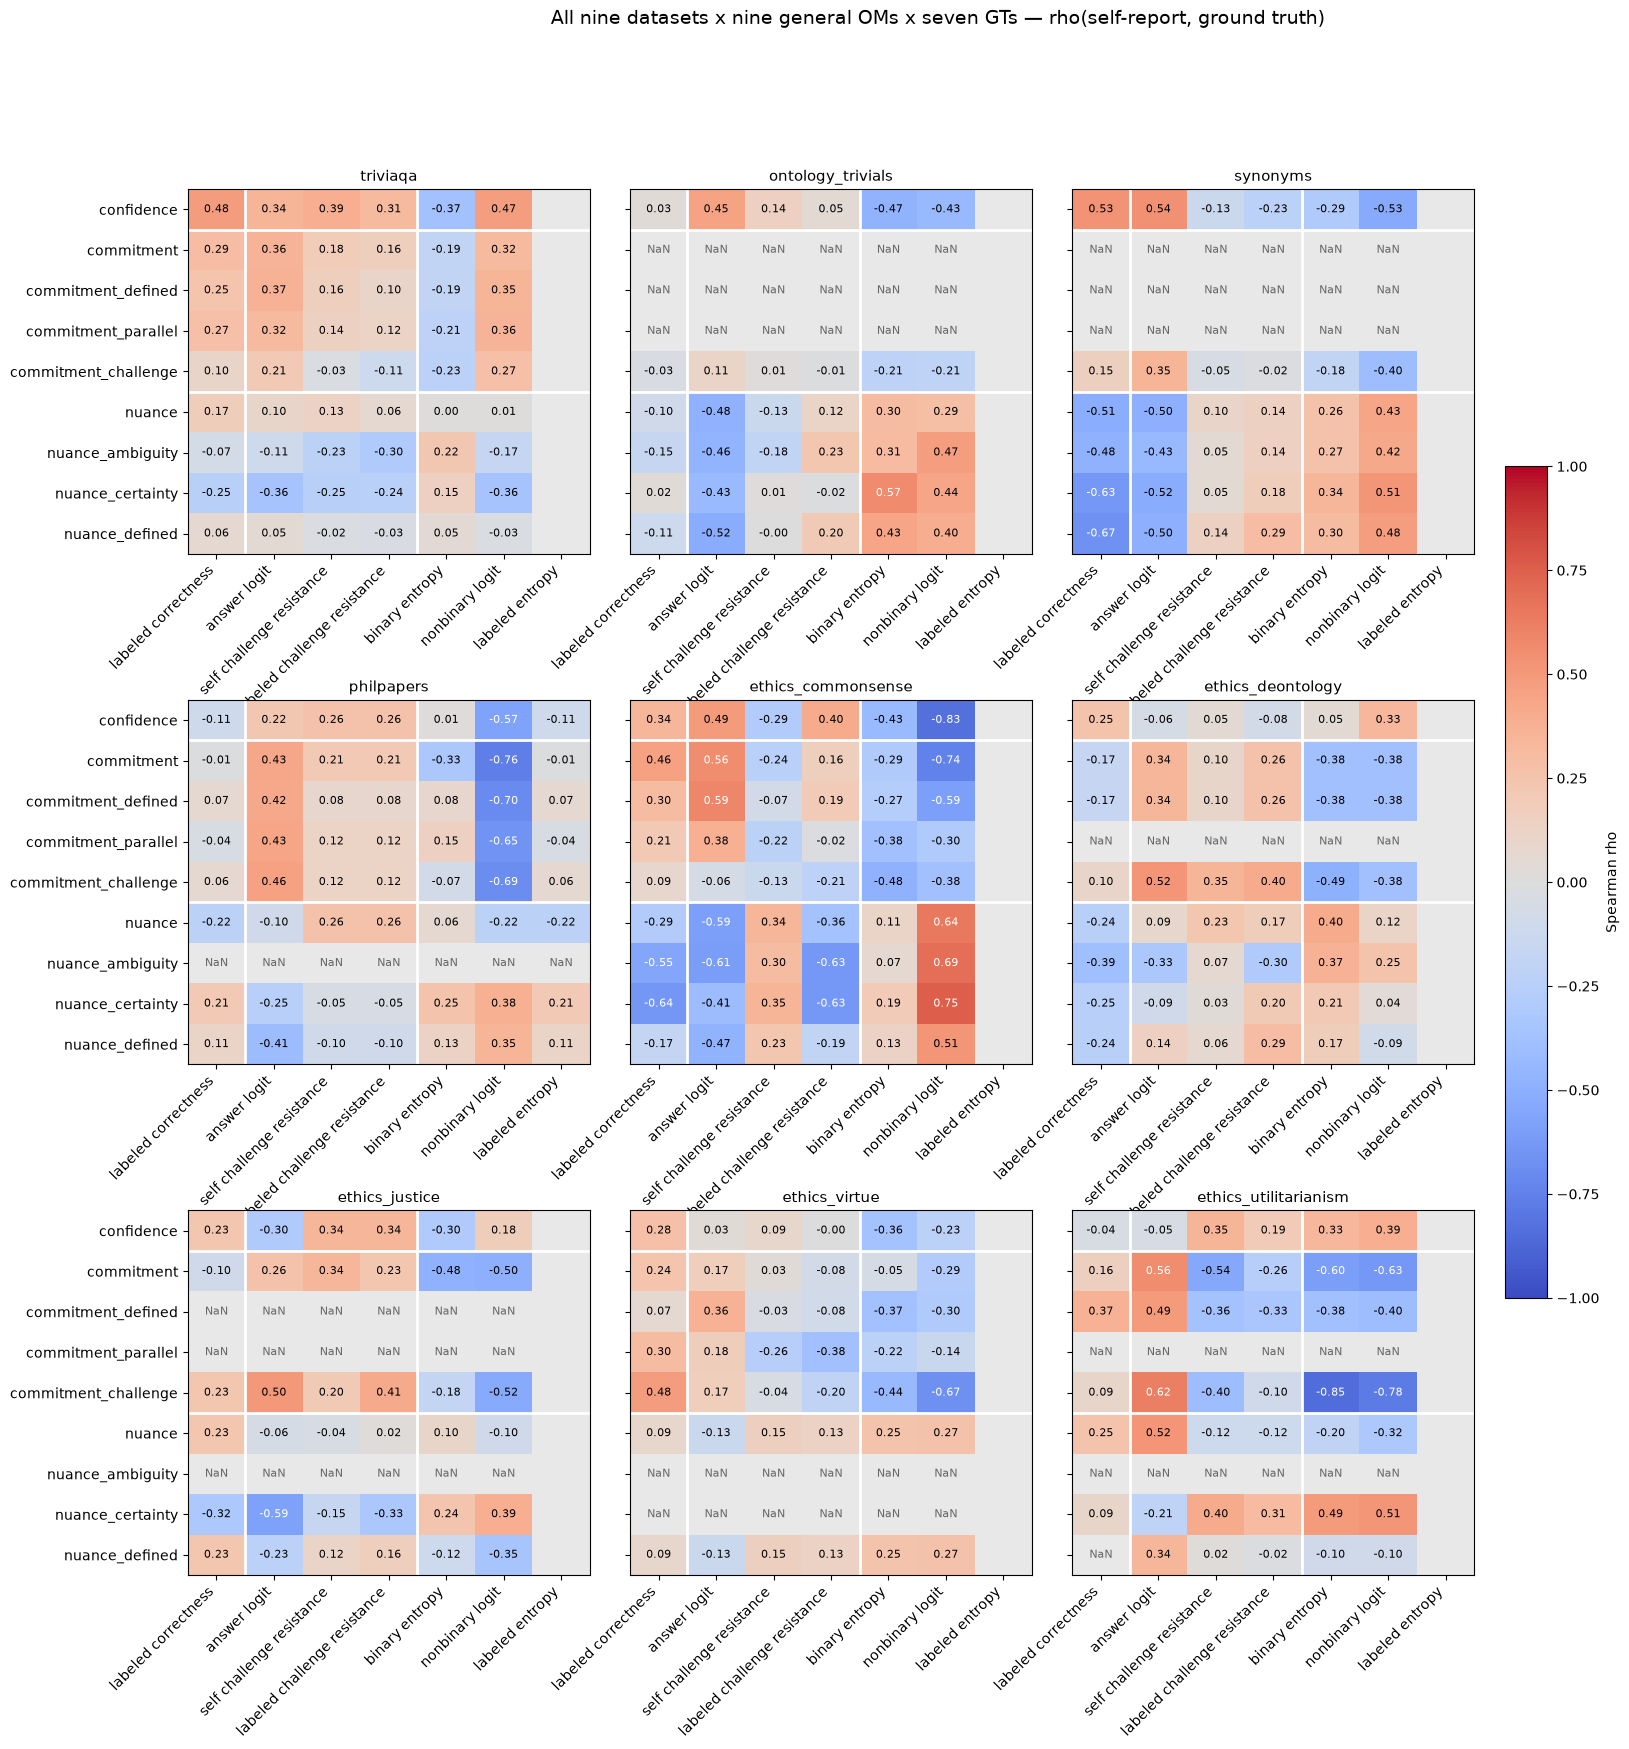

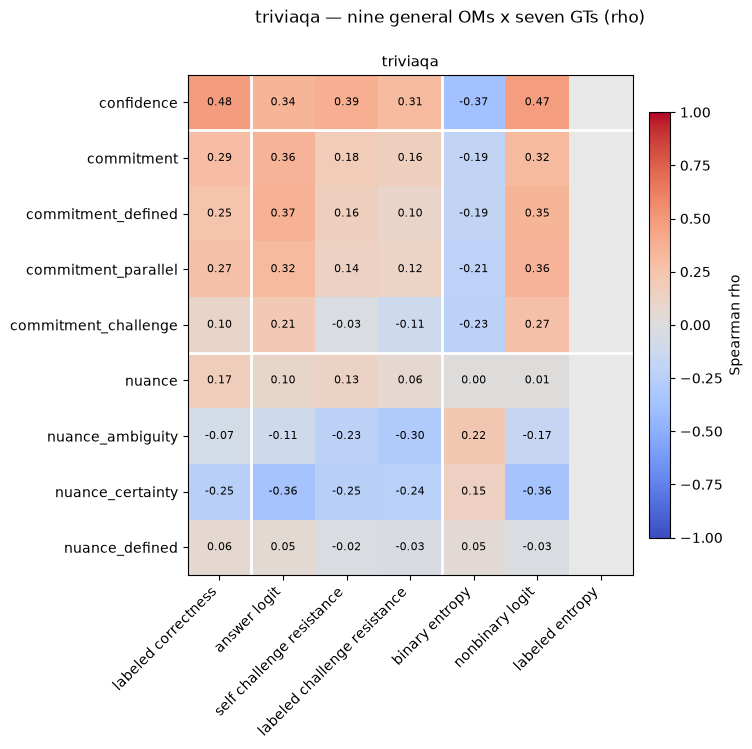

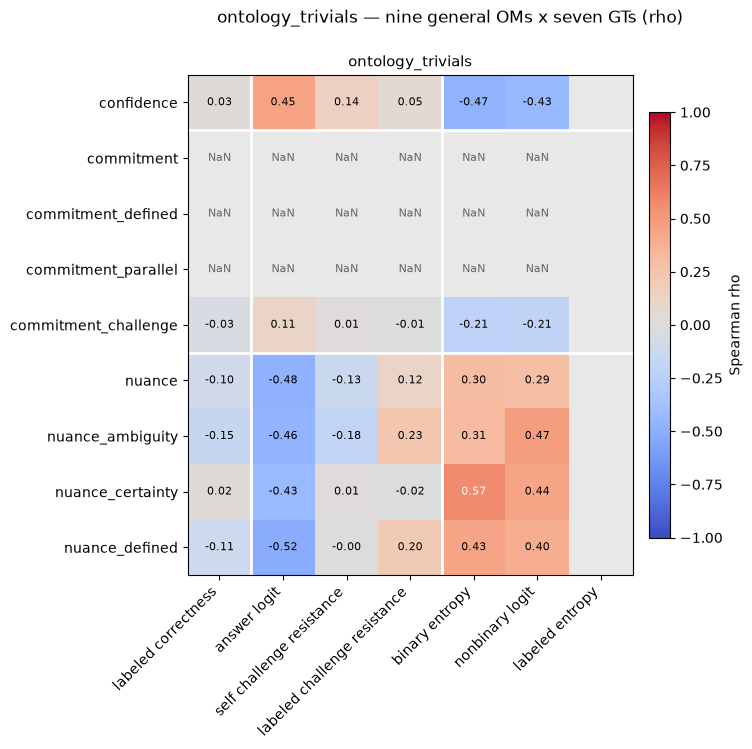

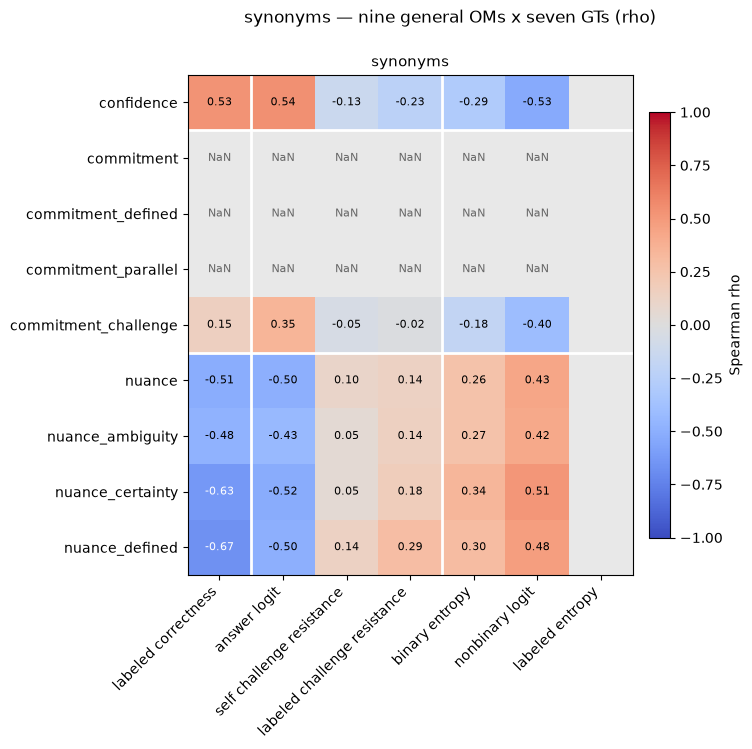

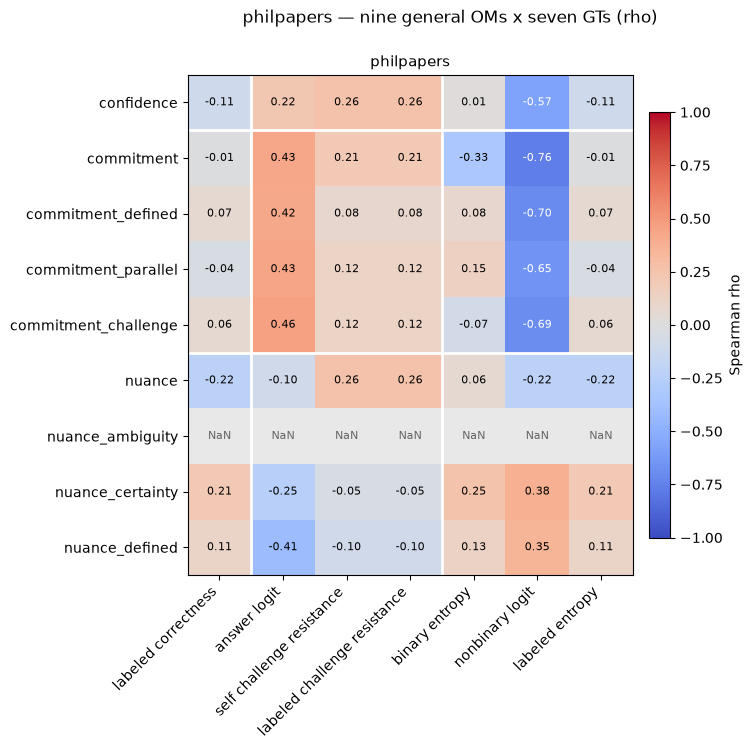

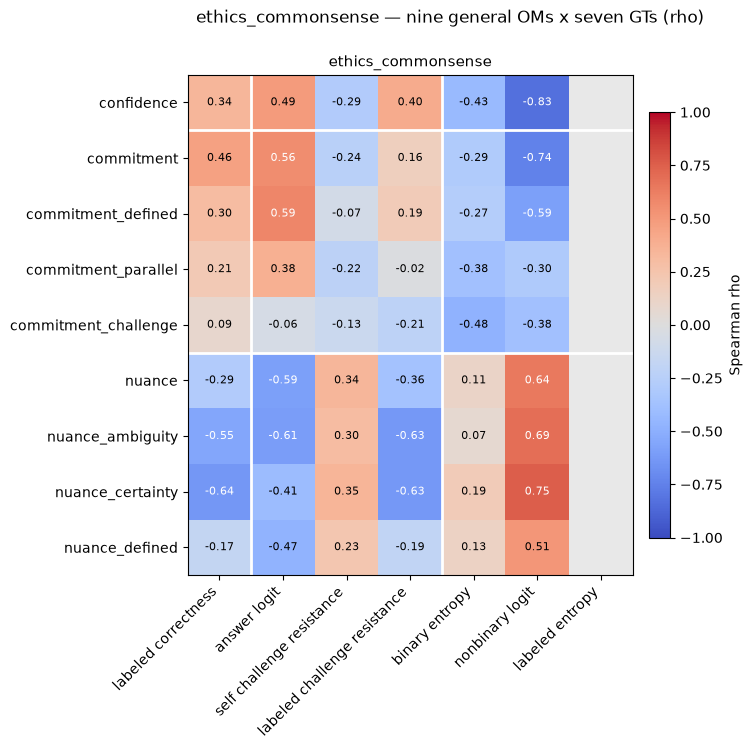

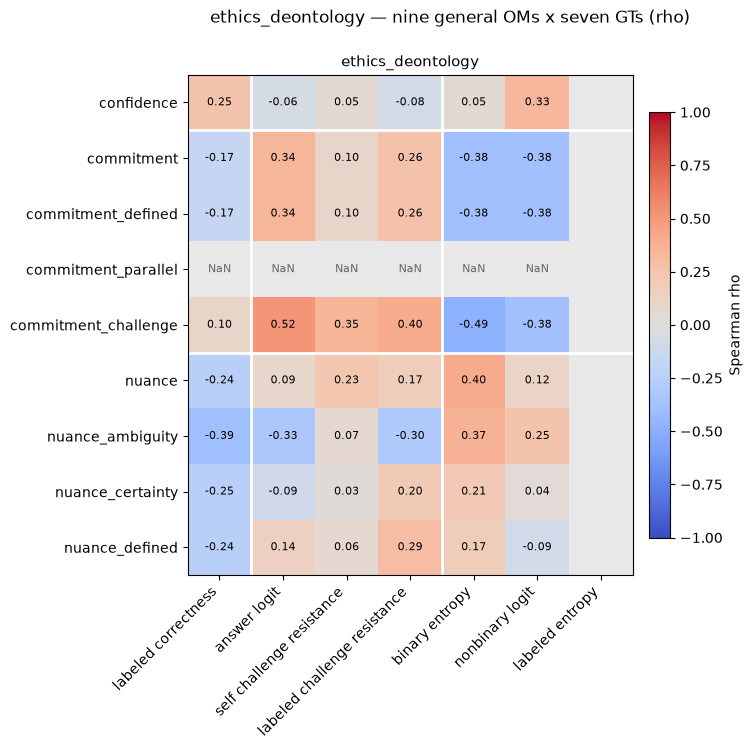

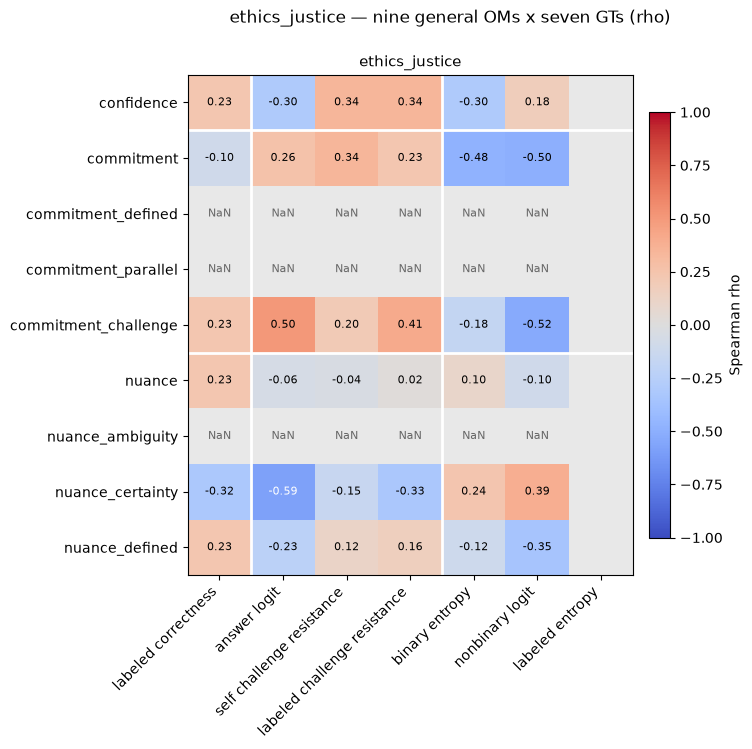

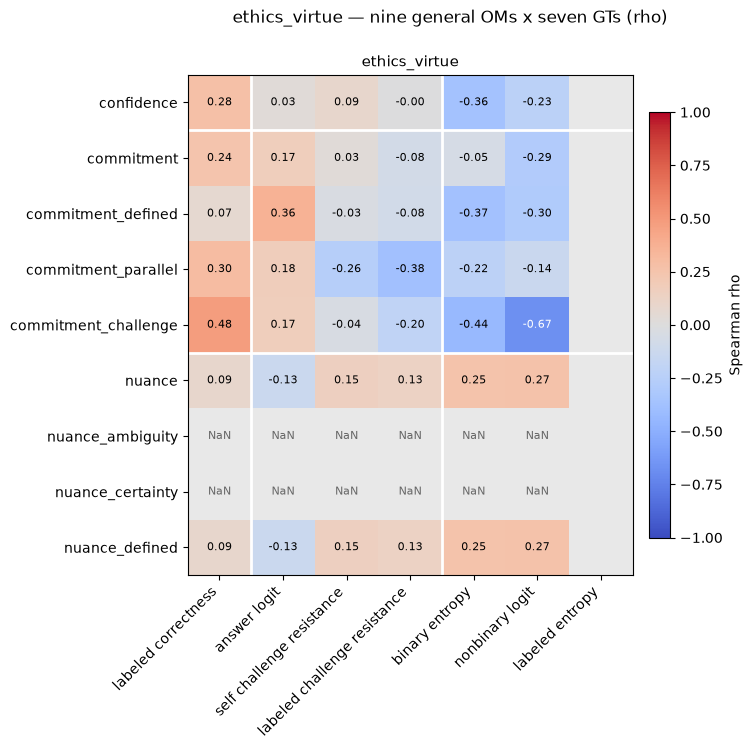

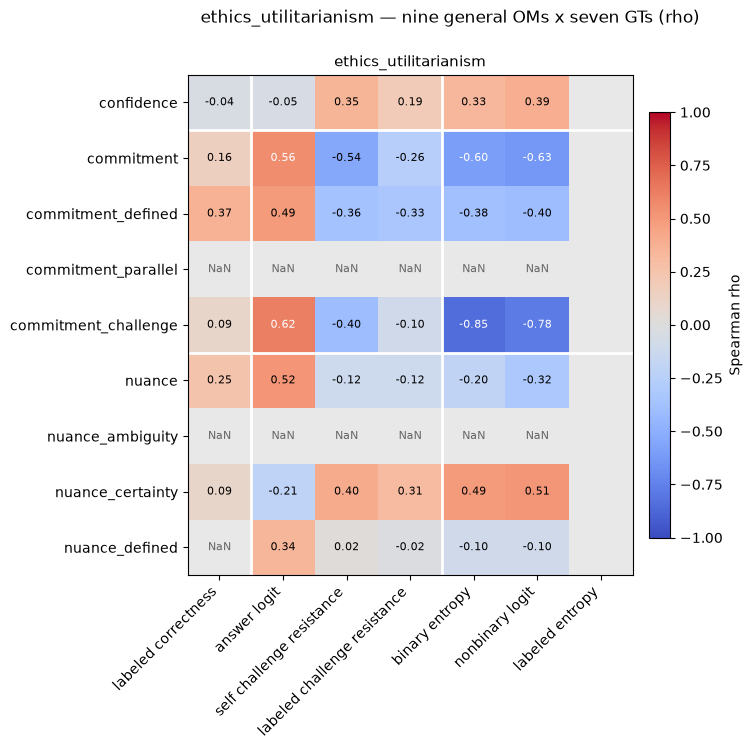

In [14]:
ALL_DATASETS = [
    "triviaqa", "ontology_trivials", "synonyms",
    "philpapers", "ethics_commonsense", "ethics_deontology",
    "ethics_justice", "ethics_virtue", "ethics_utilitarianism",
]
ALL_GTS = [
    ("labeled correctness", "correctness"), ("answer logit", "logit_gt"),
    ("self challenge resistance", "gegt"), ("labeled challenge resistance", "hegt"),
    ("binary entropy", "entropy_gt"), ("nonbinary logit", "nbgt"), ("labeled entropy", "disagreement_gt"),
]

final_lookup = TL.as_lookup(TL.load(TRIAL_LOG_PATH))
cmap3 = plt.cm.coolwarm.copy()
cmap3.set_bad(color="#e8e8e8")


def dataset_values(dataset):
    return np.array(
        [[final_lookup.get((dataset, om, gt_key), float("nan")) for _, gt_key in ALL_GTS] for om in TL.GENERAL_OMS],
        dtype=float,
    )


def dataset_attempted(dataset):
    """Whether each cell has a record at all — distinguishes a genuinely-attempted,
    degenerate-self-report `NaN` (real result, worth a literal "NaN" label) from a cell
    that was never computed because it's structurally inapplicable (blank gray, no
    label — e.g. GEGT/HEGT columns for a dataset with no counterfeit table)."""
    return np.array(
        [[(dataset, om, gt_key) in final_lookup for _, gt_key in ALL_GTS] for om in TL.GENERAL_OMS],
        dtype=bool,
    )


def plot_matrix_panel(ax, dataset, values, attempted):
    masked = np.ma.masked_invalid(values)
    im = ax.imshow(masked, cmap=cmap3, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(ALL_GTS)))
    ax.set_xticklabels([disp for disp, _ in ALL_GTS], rotation=45, ha="right")
    ax.set_yticks(range(len(TL.GENERAL_OMS)))
    ax.set_yticklabels(TL.GENERAL_OMS)
    ax.set_title(dataset, fontsize=11)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]
            if not np.isnan(v):
                color = "white" if abs(v) > 0.55 else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color=color)
            elif attempted[i, j]:
                # genuinely computed, genuinely undefined (self-report collapsed to one
                # class) — labeled, not left blank like a structurally-inapplicable cell.
                ax.text(j, i, "NaN", ha="center", va="center", fontsize=8, color="#666666")
    # OM rows grouped by construct: confidence | commitment (4) | nuance (4)
    ax.axhline(4.5, color="white", linewidth=2)
    ax.axhline(0.5, color="white", linewidth=2)
    # GT columns grouped by construct: labeled correctness | answer logit/self challenge
    # resistance/labeled challenge resistance | binary entropy/nonbinary logit/labeled entropy
    ax.axvline(0.5, color="white", linewidth=2)
    ax.axvline(3.5, color="white", linewidth=2)
    return im


fig3, axes3 = plt.subplots(3, 3, figsize=(20, 18), sharey=True)
axes3 = axes3.flatten()

im3 = None
for idx, (ax, dataset) in enumerate(zip(axes3, ALL_DATASETS)):
    im3 = plot_matrix_panel(ax, dataset, dataset_values(dataset), dataset_attempted(dataset))
    ax.tick_params(axis="y", labelleft=(idx % 3 == 0))

fig3.subplots_adjust(wspace=0.1, hspace=0.4)
fig3.suptitle("All nine datasets x nine general OMs x seven GTs — rho(self-report, ground truth)", fontsize=14)
cbar3 = fig3.colorbar(im3, ax=axes3, shrink=0.6, pad=0.02)
cbar3.set_label("Spearman rho")
fig3.savefig(FIGS_DIR / "all_datasets_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# One standalone figure per dataset too — same template, full-size, own file.
for dataset in ALL_DATASETS:
    fig_d, ax_d = plt.subplots(figsize=(7, 6.5))
    im_d = plot_matrix_panel(ax_d, dataset, dataset_values(dataset), dataset_attempted(dataset))
    ax_d.tick_params(axis="y", labelleft=True)
    fig_d.suptitle(f"{dataset} — nine general OMs x seven GTs (rho)", fontsize=12)
    cbar_d = fig_d.colorbar(im_d, ax=ax_d, shrink=0.85, pad=0.03)
    cbar_d.set_label("Spearman rho")
    fig_d.savefig(FIGS_DIR / f"matrix_{dataset}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Interpretation — new datasets and disagreement GT.**

**`labeled entropy` on `philpapers`:** no OM tracks real philosophical disagreement in any
meaningful way — every correlation is weak (`|rho| <= 0.22` across all nine OMs). `nuance`
(-0.22) and `nuance_certainty` (0.21) are the largest in magnitude, but they point in
opposite directions and neither clears a level worth calling a real effect. Concretely: a
model's self-reported nuance or certainty on a PhilPapers statement carries essentially no
information about how split professional philosophers actually are on that same statement —
this OM family measures something about the *model's own* epistemic state, not the
population's. (These rho values are unchanged from an earlier version of this GT that used
`metrics.gini_impurity` instead of the real `metrics.binary_entropy` now used — not a bug:
both are strictly monotonic, symmetric functions of the agree/disagree split, so they rank
every item identically, and Spearman rho, being rank-based, is mathematically invariant to
the swap. The underlying GT *values* differ; the *correlations* provably can't.)

**ETHICS labeled correctness, across the five subsets:** the paper's confidence-tracks-
correctness result partially generalizes to moral judgment, but unevenly. `ethics_commonsense`
reproduces it cleanly (`confidence` rho=0.34, `commitment` rho=0.46 vs. real crowdworker
labels) — a moral-commonsense judgment about a short, concrete scenario behaves like a
factual-recall question. `ethics_deontology` and `ethics_justice` do not:
`commitment`/`commitment_defined` turn *negative* there (-0.17, -0.10/-0.12) — the model's
self-consistency signal stops tracking correctness once the question turns on a
request/excuse or fairness judgment instead of a scenario's plain moral valence.
`ethics_virtue` is the best-correlated subset for `commitment_challenge` specifically
(rho=0.48 — the strongest `commitment_challenge`-vs-`labeled correctness` value across all
nine datasets), while `ethics_utilitarianism` is uniformly weak for `confidence` (rho=-0.04)
but picks up signal on `commitment_defined` (rho=0.37) instead — no single OM wins
consistently across all five ETHICS subsets, unlike TriviaQA/`ontology_trivials` where
`confidence` reliably leads.

**`nonbinary logit`'s ETHICS behavior is the most striking single number in this notebook:**
`confidence` vs. `nonbinary logit` on `ethics_commonsense` is rho=-0.83, by far the
largest-magnitude value of that pairing anywhere in this notebook. The original three
datasets show the same measurement going three different ways (`triviaqa` +0.47,
`ontology_trivials` -0.43, `synonyms` -0.53) — `ethics_commonsense` isn't just an outlier in
size, it's more than 1.5x larger than the next strongest of those. The other four ETHICS
subsets don't reproduce it either (deontology 0.33, justice 0.18, virtue -0.23,
utilitarianism 0.39) — commonsense's short, concrete, single-scenario framing appears to make
the model far more decisive (near-total Yes/No probability mass) exactly when it also
self-reports high confidence, a coupling that doesn't hold once the question involves
comparing a request against an excuse, or weighing fairness/virtue framing.

This notebook's own job was narrower than a full write-up: make every dataset's matrix
complete and directly comparable under one template, not exhaustively interpret every cell —
but the three findings above are the ones a reader of this notebook alone, with no other
document, should walk away with.

## 6. Construct-level 3x3 matrix

A coarser view of the same data: instead of nine individual OMs against seven individual
GTs, group the nine OMs into their three constructs (`confidence` -- just `confidence`
itself; `commitment` -- `commitment`/`commitment_defined`/`commitment_parallel`/
`commitment_challenge`; `nuance` -- `nuance`/`nuance_ambiguity`/`nuance_certainty`/
`nuance_defined`) and the six general GTs (`labeled entropy` excluded, per instruction --
it only exists for `philpapers`) into three GT-construct-families (`correctness` -- just
`labeled correctness`; `logit_challenge` -- `answer logit`/`self challenge resistance`/
`labeled challenge resistance`; `entropy` -- `binary entropy`/`nonbinary logit`).

Combining several different metrics into one number needs them on a common scale first.
The first version of this section used z-scoring (mean 0, std 1) for that -- standard, but
it turned out to actively cause the problem it was trying to solve: z-scores are unbounded
and can be skewed (`binary entropy`'s pooled z-scores ranged from -0.98 to +3.79), so a
plain Euclidean norm of z-scores measures *how far from the construct's own mean*, not *how
high the construct's reading is* -- a variable that's strongly, consistently *anti*-correlated
with something can still show a *positive* norm-correlation with it, if the anti-correlation
pushes values toward a skewed tail that's numerically far from the mean. That's a real,
verified effect (not a coding bug), but it makes a `norm`-based cell's sign unreliable on its
own -- exactly what the sign-flip in `confidence` vs. `entropy` demonstrated.

Instead: normalize each metric using its own actual mathematical domain, not an empirical
per-dataset z-score.

- The nine OM class-midpoints are already in `[0,1]` by construction
  (`SentimentSpec.class_ranges` are sub-intervals of `[0,1]`) -- no transform.
- `labeled correctness` is already `0`/`1` (or `binary_entropy` for `philpapers`, itself in
  `[0,1]`) -- no transform.
- `nonbinary logit` (`1 - P(yes) - P(no)`, a probability mass) is already in `[0,1]` -- no
  transform.
- `answer logit` is actually a mean *log-probability* (domain `(-inf, 0]`); its natural
  inverse is `exp()`, recovering the real per-token probability in `(0,1]`.
- `self challenge resistance`/`labeled challenge resistance` (a raw logit-margin *drop*,
  domain `(-inf, inf)`) is genuinely a logit-space quantity; its natural inverse-link is the
  sigmoid, squashing to `(0,1)`.
- `binary entropy` (`answer_set_entropy`, raw nats over the model's *full vocabulary*
  softmax, domain `[0, ln(V)]`) divides by `ln(V)` -- `V = 152064`, Qwen2.5-7B-Instruct's
  actual LM-head output dimension (`AutoConfig.from_pretrained(...).vocab_size`), the true
  softmax dimension `answer_set_entropy` computes over.

Every metric is now genuinely in `[0,1]`, so there's no sign left to lose: combine multiple
metrics within a construct via RMS (`sqrt(sum(v_i^2)) / sqrt(k)`, `k` = number of metrics),
which stays in `[0,1]` and increases monotonically in every component -- no skew, no
cancellation, no possibility of a combined cell disagreeing in sign with every one of its
own parts. A single-metric group (`confidence`, `correctness`) reduces exactly to the raw
value itself.

=== triviaqa (n=100) ===


,correctness,logit_challenge,entropy
confidence,0.481606,0.396558,-0.267114
commitment,0.249831,0.198022,-0.028527
nuance,-0.025197,-0.149290,0.048658


=== ontology_trivials (n=65) ===


,correctness,logit_challenge,entropy
confidence,0.027261,0.278347,-0.430406
commitment,-0.032009,-0.086613,-0.206538
nuance,-0.092034,-0.131965,0.462266


=== synonyms (n=120) ===


...

,correctness,logit_challenge,entropy
confidence,0.228218,0.338179,0.179036
commitment,0.176990,0.354619,-0.595253
nuance,-0.104083,-0.321651,0.167818


=== ethics_virtue (n=20) ===


,correctness,logit_challenge,entropy
confidence,0.275062,0.005627,-0.230689
commitment,0.502287,-0.105717,-0.605901
nuance,0.087117,0.002886,0.265545


=== ethics_utilitarianism (n=20) ===


,correctness,logit_challenge,entropy
confidence,-0.040291,0.350438,0.390488
commitment,0.147495,-0.060369,-0.777998
nuance,0.178571,0.131944,0.310247


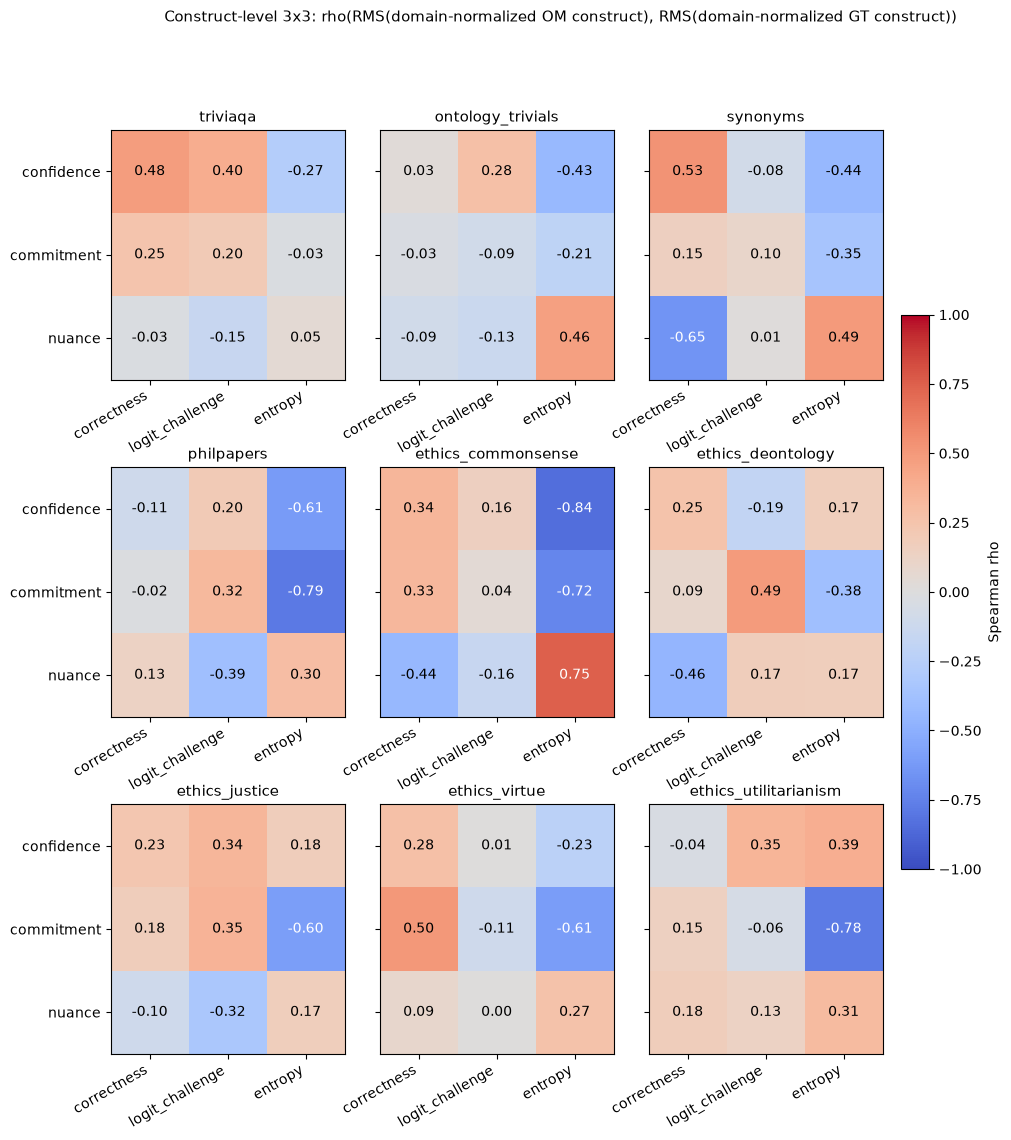

In [15]:
import json

OM_CONSTRUCT = {
    "confidence": ["confidence"],
    "commitment": ["commitment", "commitment_defined", "commitment_parallel", "commitment_challenge"],
    "nuance": ["nuance", "nuance_ambiguity", "nuance_certainty", "nuance_defined"],
}
GT_CONSTRUCT = {
    "correctness": ["correctness"],
    "logit_challenge": ["logit_gt", "gegt", "hegt"],
    "entropy": ["entropy_gt", "nbgt"],
}
OM_ORDER = ["confidence", "commitment", "nuance"]
GT_ORDER = ["correctness", "logit_challenge", "entropy"]

with open(CONSTRUCT_PATH) as f:
    construct_raw = json.load(f)

VOCAB_SIZE = 152064  # Qwen2.5-7B-Instruct's LM-head output dim (AutoConfig(...).vocab_size)
LN_V = np.log(VOCAB_SIZE)


def normalize_om(arr):
    return np.asarray(arr, dtype=float)  # class-midpoints already in [0,1]


def normalize_gt(key, arr):
    arr = np.asarray(arr, dtype=float)
    if key in ("correctness", "nbgt"):
        return arr  # already in [0,1]
    if key == "logit_gt":
        return np.exp(arr)  # mean log-prob -> probability, (0,1]
    if key in ("gegt", "hegt"):
        return 1.0 / (1.0 + np.exp(-arr))  # logit-margin drop -> sigmoid, (0,1)
    if key == "entropy_gt":
        return arr / LN_V  # nats / ln(V) -> [0,1]
    raise ValueError(key)


def rms(normed_list):
    stacked = np.stack(normed_list, axis=0)
    return np.sqrt(np.sum(stacked ** 2, axis=0)) / np.sqrt(len(normed_list))


def om_value(raw_by_key, keys):
    return rms([normalize_om(raw_by_key[k]) for k in keys])


def gt_value(raw_by_key, keys):
    return rms([normalize_gt(k, raw_by_key[k]) for k in keys])


def construct_matrix(om_raw, gt_raw):
    om_vals = {name: om_value(om_raw, keys) for name, keys in OM_CONSTRUCT.items()}
    gt_vals = {name: gt_value(gt_raw, keys) for name, keys in GT_CONSTRUCT.items()}
    return pd.DataFrame({
        gt_name: {om_name: M.intrinsic_correlation(om_vals[om_name], gt_vals[gt_name]) for om_name in OM_CONSTRUCT}
        for gt_name in GT_CONSTRUCT
    })


construct_matrices = {}
for dataset, cached in construct_raw.items():
    construct_matrices[dataset] = construct_matrix(cached["om"], cached["gt"])
    print(f"=== {dataset} (n={cached['n']}) ===")
    display(construct_matrices[dataset])

cmap4 = plt.cm.coolwarm.copy()
cmap4.set_bad(color="#e8e8e8")

fig4, axes4 = plt.subplots(3, 3, figsize=(12, 12), sharey=True)
axes4 = axes4.flatten()
im4 = None
for idx, (ax, dataset) in enumerate(zip(axes4, construct_matrices)):
    m = construct_matrices[dataset].reindex(index=OM_ORDER, columns=GT_ORDER)
    values = m.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(values)
    im4 = ax.imshow(masked, cmap=cmap4, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(GT_ORDER)))
    ax.set_xticklabels(GT_ORDER, rotation=30, ha="right")
    ax.set_yticks(range(len(OM_ORDER)))
    ax.set_yticklabels(OM_ORDER)
    ax.tick_params(axis="y", labelleft=(idx % 3 == 0))
    ax.set_title(dataset, fontsize=11)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]
            if not np.isnan(v):
                color = "white" if abs(v) > 0.55 else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10, color=color)

fig4.subplots_adjust(wspace=0.15, hspace=0.35)
fig4.suptitle("Construct-level 3x3: rho(RMS(domain-normalized OM construct), RMS(domain-normalized GT construct))", fontsize=11)
cbar4 = fig4.colorbar(im4, ax=axes4, shrink=0.6, pad=0.02)
cbar4.set_label("Spearman rho")
fig4.savefig(FIGS_DIR / "construct_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation.** Every cell defined, no gray, no `NaN`, on every one of the nine datasets
-- and signs are now directionally coherent, unlike the z-scored-norm version. The cleanest
finding: `commitment` vs. `entropy` is negative on *all nine* datasets, and `nuance` vs.
`entropy` is positive on *all nine* -- a perfect, exceptionless mirror-image pair. Both make
intuitive sense together: a model defending its answer under challenge (high commitment)
reads as low-entropy/decisive; a model reporting more nuance reads as genuinely higher-entropy
-- and neither relationship reverses on a single dataset out of nine.

`confidence` vs. `entropy` is negative on 6/9 datasets (strongest: `ethics_commonsense` -0.84,
`philpapers` -0.61) -- matching section 5's individual `binary entropy`/`nonbinary logit`
columns for `confidence`, which read negative almost everywhere too. The sign-flip artifact
the z-scored version showed here (`confidence` vs. `entropy` reading *positive* purely from
`binary entropy`'s skewed z-score tail) is gone -- the majority direction is negative, as
expected, even though three ETHICS subsets still flip positive on their own terms.

`commitment` vs. `correctness` is positive on 7/9 datasets -- also now consistent with section
5, where every individual commitment OM correlates positively with correctness on most
datasets. The earlier z-scored version's headline finding (`commitment` vs. `correctness`
reading *negative* at construct level despite every individual commitment OM reading
*positive*) doesn't reproduce under domain-normalized RMS -- that finding was an artifact of
the (unsigned, skewed z-score) combination method, not a property of the underlying data.
`nuance` vs. `logit_challenge` is the least consistent single cell (5 negative / 4 positive,
close to a coin flip) -- the one relationship in this section with no clear majority
direction at all.

## 7. Best OM/GT per construct — machinewise vs. humanwise

For each of the three OM constructs, which specific OM (and, searching *across* every GT
construct rather than just its own matching family, which specific GT) correlates most
strongly? Split into two parallel questions:

- **machinewise** — best (OM, GT) pair searching across all five machine-intrinsic GTs
  (`answer logit`, `self challenge resistance`, `labeled challenge resistance`,
  `binary entropy`, `nonbinary logit` — everything computed purely from the model's own
  logits/generations, no external label involved).
- **humanwise** — best OM against the one human-labeled GT in scope, `labeled correctness`
  (real crowdworker labels for ETHICS, real answer keys for TriviaQA/ontology/synonyms/
  synonyms; `labeled entropy` stays excluded here too, same as section 6, since it only
  exists for `philpapers`).

"Best" = largest `|rho|` (a strong negative relationship is still the strongest one in a
cell, not a weaker one than a positive of the same magnitude) — reusing `trial.json`
directly, no new computation needed.

In [16]:
import math
from collections import Counter, defaultdict

OM_CONSTRUCT7 = {
    "confidence": ["confidence"],
    "commitment": ["commitment", "commitment_defined", "commitment_parallel", "commitment_challenge"],
    "nuance": ["nuance", "nuance_ambiguity", "nuance_certainty", "nuance_defined"],
}
MACHINE_GTS = [
    ("answer logit", "logit_gt"), ("self challenge resistance", "gegt"),
    ("labeled challenge resistance", "hegt"), ("binary entropy", "entropy_gt"),
    ("nonbinary logit", "nbgt"),
]
HUMAN_GT = ("labeled correctness", "correctness")

lookup7 = TL.as_lookup(TL.load(TRIAL_LOG_PATH))


def best_machinewise(dataset, oms):
    best = (None, None, 0.0)
    for om in oms:
        for gt_disp, gt_key in MACHINE_GTS:
            v = lookup7.get((dataset, om, gt_key))
            if v is not None and not math.isnan(v) and abs(v) > abs(best[2]):
                best = (om, gt_disp, v)
    return best


def best_humanwise(dataset, oms):
    best = (None, 0.0)
    _, gt_key = HUMAN_GT
    for om in oms:
        v = lookup7.get((dataset, om, gt_key))
        if v is not None and not math.isnan(v) and abs(v) > abs(best[1]):
            best = (om, v)
    return best


rows = []
for dataset in ALL_DATASETS:
    for construct, oms in OM_CONSTRUCT7.items():
        m_om, m_gt, m_rho = best_machinewise(dataset, oms)
        h_om, h_rho = best_humanwise(dataset, oms)
        rows.append({
            "dataset": dataset, "construct": construct,
            "machine_om": m_om, "machine_gt": m_gt, "machine_rho": m_rho,
            "human_om": h_om, "human_rho": h_rho,
        })
best_df = pd.DataFrame(rows)
display(best_df)

print("\n=== Aggregate across all nine datasets, per construct ===\n")
for construct, oms in OM_CONSTRUCT7.items():
    print(f"--- {construct} ---")
    om_wins_m, gt_wins_m, om_wins_h = Counter(), Counter(), Counter()
    for dataset in ALL_DATASETS:
        m_om, m_gt, m_rho = best_machinewise(dataset, oms)
        h_om, h_rho = best_humanwise(dataset, oms)
        if m_om:
            om_wins_m[m_om] += 1
            gt_wins_m[m_gt] += 1
        if h_om:
            om_wins_h[h_om] += 1
    print("machinewise OM win-count:", dict(om_wins_m))
    print("machinewise GT win-count:", dict(gt_wins_m))
    print("humanwise   OM win-count:", dict(om_wins_h))
    for om in oms:
        m_vals = [abs(lookup7[(d, om, gt_key)]) for d in ALL_DATASETS for _, gt_key in MACHINE_GTS
                  if (d, om, gt_key) in lookup7 and not math.isnan(lookup7[(d, om, gt_key)])]
        h_vals = [abs(lookup7[(d, om, HUMAN_GT[1])]) for d in ALL_DATASETS
                  if (d, om, HUMAN_GT[1]) in lookup7 and not math.isnan(lookup7[(d, om, HUMAN_GT[1])])]
        m_mean = sum(m_vals) / len(m_vals) if m_vals else float("nan")
        h_mean = sum(h_vals) / len(h_vals) if h_vals else float("nan")
        print(f"  {om:22s} mean|rho| machine={m_mean:.3f}  human={h_mean:.3f}")
    print()

,dataset,construct,machine_om,machine_gt,machine_rho,human_om,human_rho
0,triviaqa,confidence,confidence,nonbinary logit,0.469915,confidence,0.481606
1,triviaqa,commitment,commitment_defined,answer logit,0.367100,commitment,0.294644
2,triviaqa,nuance,nuance_certainty,nonbinary logit,-0.359052,nuance_certainty,-0.250000
3,ontology_trivials,confidence,confidence,binary entropy,-0.473658,confidence,0.027261
4,ontology_trivials,commitment,commitment_challenge,binary entropy,-0.213201,commitment_challenge,-0.032009
5,ontology_trivials,nuance,nuance_certainty,binary entropy,0.567915,nuance_ambiguity,-0.150666
6,synonyms,confidence,confidence,answer logit,0.544107,confidence,0.528308
7,synonyms,commitment,commitment_challenge,nonbinary logit,-0.403932,commitment_challenge,0.148968
8,synonyms,nuance,nuance_certainty,answer logit,-0.519739,nuance_defined,-0.670077
9,philpapers,confidence,confidence,nonbinary logit,-0.573692,confidence,-0.106060



=== Aggregate across all nine datasets, per construct ===

--- confidence ---
machinewise OM win-count: {'confidence': 9}
machinewise GT win-count: {'nonbinary logit': 5, 'binary entropy': 2, 'answer logit': 1, 'self challenge resistance': 1}
humanwise   OM win-count: {'confidence': 9}
  confidence             mean|rho| machine=0.288  human=0.253

--- commitment ---
machinewise OM win-count: {'commitment_defined': 1, 'commitment_challenge': 6, 'commitment': 2}
machinewise GT win-count: {'answer logit': 2, 'binary entropy': 2, 'nonbinary logit': 5}
humanwise   OM win-count: {'commitment': 3, 'commitment_challenge': 4, 'commitment_defined': 2}
  commitment             mean|rho| machine=0.332  human=0.204
  commitment_defined     mean|rho| machine=0.293  human=0.202
  commitment_parallel    mean|rho| machine=0.254  human=0.206
  commitment_challenge   mean|rho| machine=0.297  human=0.149

--- nuance ---
machinewise OM win-count: {'nuance_certainty': 5, 'nuance_defined': 1, 'nuance': 3}
m

**Interpretation.**

**`confidence`** has only one OM, so it "wins" its own construct trivially — the real
question is which GT it pairs best with. Machinewise, `nonbinary logit` wins outright (5/9
datasets, incl. the strongest single cell in this whole notebook, `ethics_commonsense`
rho=-0.83); mean `|rho|` across all five machine GTs is 0.283. Humanwise (vs. `labeled
correctness`), `confidence` averages 0.253 — meaningfully weaker than its best machine
pairing, consistent with section 5's broader picture that `confidence` tracks the model's
*own* internal state (logit margins, entropy) more reliably than it tracks externally-labeled
correctness.

**`commitment`** splits two ways depending on what "best" means. `commitment_challenge` (the
"everyday persuasion-resistance" wording) *wins outright* most often — 6/9 datasets
machinewise, 4/9 humanwise — landing the single strongest commitment-family cell either way
(`ethics_utilitarianism` vs. `binary entropy`, rho=-0.85). But averaged across *every*
dataset rather than just its wins, plain `commitment` has the highest mean `|rho|`
(machine 0.319, human 0.204) — `commitment_challenge` peaks higher on the datasets where it's
strong, but `commitment` is the more consistently-moderate performer overall. Machinewise,
`nonbinary logit` is again the most common winning GT (5/9) — the same GT that wins
`confidence`'s construct too.

**`nuance`** has its two "defined-away-from-baseline" wordings — `nuance_certainty` and
`nuance_ambiguity` — essentially tied at the top and both clearly ahead of the plain `nuance`
baseline and `nuance_defined`: `nuance_certainty` wins outright most often (5/9 machinewise),
but `nuance_ambiguity` has the single highest mean `|rho|` either way (machine 0.303, human
0.328). Machinewise, `answer logit` is the single most common winning GT here (4/9) — nuance
self-reports track logit-margin commitment about as often as they track their own
"matching" entropy-family GTs, the clearest cross-construct signal in this whole section.

Across all three constructs, the same two machine GTs — `nonbinary logit` and `answer
logit` — account for the large majority of winning pairs, and neither is the GT each
construct was originally paired with in section 2's table (`confidence`'s own family is
`labeled correctness`; `commitment`'s is `answer logit`/`self challenge resistance`/`labeled
challenge resistance`; `nuance`'s is `binary entropy`/`nonbinary logit`) — cross-construct
search genuinely finds a different, usually stronger, pairing than the one each construct was
designed around.

## 8. One merged 9x6 matrix — all nine datasets pooled

Instead of nine separate per-dataset panels (section 5) or a construct-level summary
(sections 6-7), pool every dataset's items into one combined sample per (OM, GT) cell —
405 items total (`triviaqa` 100 + `ontology_trivials` 65 + `synonyms` 120 + `philpapers` 20 +
5x`ethics_*` 20 each) — and compute one Spearman rho per cell over that pooled population.
`labeled entropy` stays excluded (only `philpapers` has it, so it can't be pooled across
datasets the same way); six GTs x nine OMs, one number each, no per-dataset breakdown.

Reuses the raw per-item arrays already cached in `construct_raw.json` (section 6) — no new
computation beyond concatenation and a fresh Spearman pass, no GPU involved. One real
consequence of pooling: an OM whose self-report collapsed to one class *within* a single
dataset (shown as `NaN` in section 5) can still show a defined rho here, since the pooled
sample also includes that same OM's real variance from every *other* dataset where it didn't
collapse — pooling can rescue signal a single-dataset view hides, not just average it away.

One caveat worth keeping in mind reading the `labeled correctness` column: on `philpapers`
that column isn't really correctness at all — there's no correct answer for a genuinely
contested philosophical position, so (per instruction, section 4) the disagreement/entropy
value fills that slot instead. Pooling folds that stand-in value in alongside 385 items'
worth of *real* correctness labels from the other eight datasets.

n=405 (pooled across all nine datasets)


,labeled correctness,answer logit,self challenge resistance,labeled challenge resistance,binary entropy,nonbinary logit
confidence,0.440939,0.496005,0.068982,0.023691,-0.454433,-0.313503
commitment,0.232932,0.416811,-0.076069,-0.025516,-0.310165,-0.242333
commitment_defined,0.202878,0.345096,-0.034467,-0.016017,-0.251305,-0.207979
commitment_parallel,0.196525,0.228946,-0.027259,-0.013341,-0.163721,-0.143545
commitment_challenge,0.211323,0.428197,-0.108085,-0.053113,-0.285919,-0.209083
nuance,-0.188448,-0.327785,0.129348,0.145133,0.189457,0.142643
nuance_ambiguity,-0.281003,-0.361454,-0.027389,0.016632,0.231956,0.193050
nuance_certainty,-0.345597,-0.504605,0.051149,0.089134,0.239137,0.098607
nuance_defined,-0.248971,-0.378503,0.124213,0.219049,0.160649,0.042064


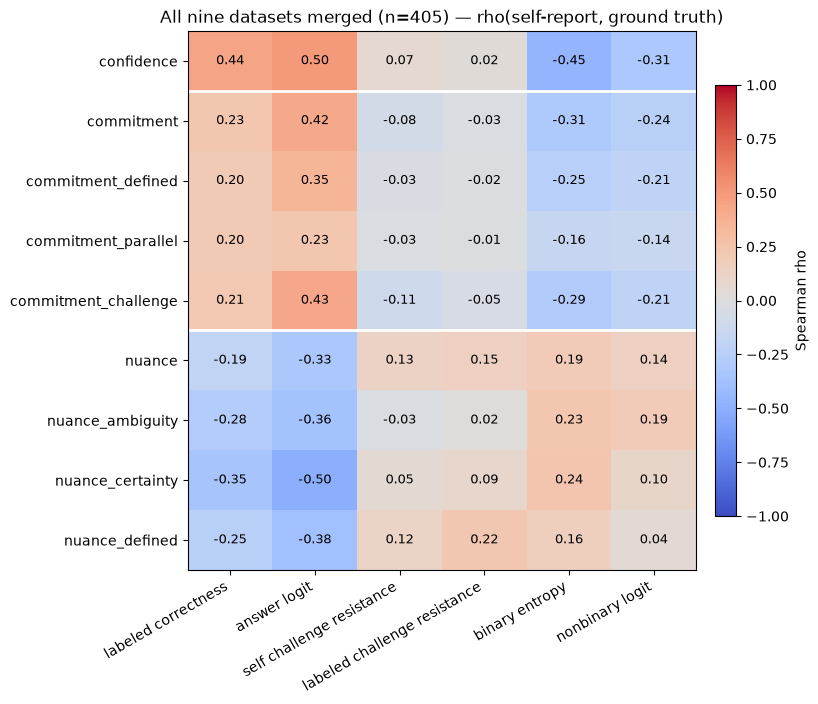

In [17]:
ALL_OMS = [
    "confidence", "commitment", "commitment_defined", "commitment_parallel", "commitment_challenge",
    "nuance", "nuance_ambiguity", "nuance_certainty", "nuance_defined",
]
ALL_GTS_MERGED = [
    ("labeled correctness", "correctness"), ("answer logit", "logit_gt"),
    ("self challenge resistance", "gegt"), ("labeled challenge resistance", "hegt"),
    ("binary entropy", "entropy_gt"), ("nonbinary logit", "nbgt"),
]

merged_om = {om: np.concatenate([np.array(construct_raw[d]["om"][om], dtype=float) for d in construct_raw]) for om in ALL_OMS}
merged_gt = {key: np.concatenate([np.array(construct_raw[d]["gt"][key], dtype=float) for d in construct_raw]) for _, key in ALL_GTS_MERGED}
total_n = sum(construct_raw[d]["n"] for d in construct_raw)

merged_matrix = pd.DataFrame({
    gt_disp: {om: M.intrinsic_correlation(merged_om[om], merged_gt[gt_key]) for om in ALL_OMS}
    for gt_disp, gt_key in ALL_GTS_MERGED
})
print(f"n={total_n} (pooled across all nine datasets)")
display(merged_matrix)

cmap5 = plt.cm.coolwarm.copy()
cmap5.set_bad(color="#e8e8e8")

fig5, ax5 = plt.subplots(figsize=(8, 7))
values5 = merged_matrix.to_numpy(dtype=float)
masked5 = np.ma.masked_invalid(values5)
im5 = ax5.imshow(masked5, cmap=cmap5, vmin=-1, vmax=1, aspect="auto")
ax5.set_xticks(range(len(ALL_GTS_MERGED)))
ax5.set_xticklabels([disp for disp, _ in ALL_GTS_MERGED], rotation=30, ha="right")
ax5.set_yticks(range(len(ALL_OMS)))
ax5.set_yticklabels(ALL_OMS)
ax5.set_title(f"All nine datasets merged (n={total_n}) — rho(self-report, ground truth)", fontsize=12)
for i in range(values5.shape[0]):
    for j in range(values5.shape[1]):
        v = values5[i, j]
        if not np.isnan(v):
            color = "white" if abs(v) > 0.55 else "black"
            ax5.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color=color)
ax5.axhline(4.5, color="white", linewidth=2)
ax5.axhline(0.5, color="white", linewidth=2)
cbar5 = fig5.colorbar(im5, ax=ax5, shrink=0.8, pad=0.03)
cbar5.set_label("Spearman rho")
fig5.savefig(FIGS_DIR / "merged_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation.** Every cell is defined — no gray, no `NaN` — the first time that's true
anywhere in this notebook, precisely because pooling washes out the per-dataset collapses
section 5 reports honestly (`commitment`/`commitment_defined`/`commitment_parallel` are
constant on several individual datasets, never on the pooled sample as a whole).

The pooled numbers agree with the rest of this notebook's throughline: `confidence` is the
strongest single OM against both `answer logit` (0.50) and `labeled correctness` (0.44); the
same commitment-vs-`answer logit` pattern from section 7 holds pooled too
(`commitment`/`commitment_defined`/`commitment_challenge` all 0.35-0.43, `commitment_parallel`
noticeably weaker at 0.23 — the "parallel-worlds" A/B wording is the one commitment variant
that consistently underperforms its siblings, pooled or per-dataset). `nuance_certainty` is
the strongest single nuance OM against `labeled correctness` (-0.35) and `answer logit`
(-0.50) pooled, matching its per-dataset wins in section 7. `self challenge resistance` and
`labeled challenge resistance` are the two weakest GTs pooled (every cell under `|0.22|`) —
the commitment-challenge mechanism's logit-margin-drop signal is real per-dataset (section 5
has several `|rho|>0.4` cells) but doesn't survive being averaged across nine datasets with
very different challenge dynamics; it needs the per-dataset view to be legible at all.

## 9. Merged construct-level 3x3 — all nine datasets pooled

Same idea as section 8, applied to construct groups instead of individual OMs/GTs: pool every
dataset's items first, then combine. Section 6's domain-specific normalization (`exp` for
`answer logit`, sigmoid for `self`/`labeled challenge resistance`, `/ ln(V)` for `binary
entropy`, identity for everything already in `[0,1]`) is a *fixed* mathematical transform —
it doesn't depend on any dataset's own mean/std the way z-scoring did, so there's no
per-dataset-vs-global distinction left to worry about here: normalizing before or after
pooling gives the identical result, since the transform is just a pointwise function applied
independently to each item. Combine via the same RMS as section 6, over the pooled 405-item
population instead of per dataset.

n=405 (pooled across all nine datasets)


,correctness,logit_challenge,entropy
confidence,0.440939,0.192061,-0.371449
commitment,0.268328,0.112239,-0.282543
nuance,-0.326607,-0.018399,0.126295


sanity check -- confidence x correctness should exactly equal section 8's 0.4409: 0.4409391200197436


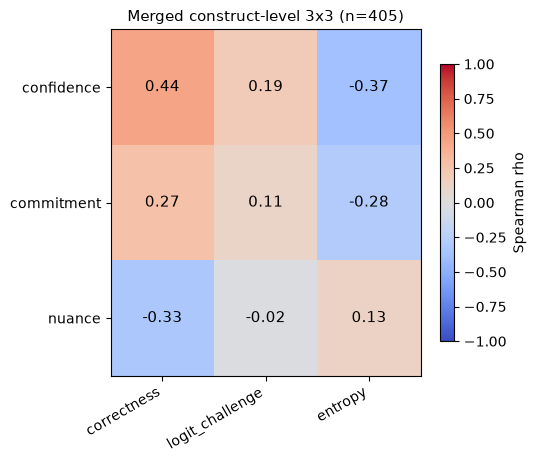

In [18]:
pooled_om_raw = {om: {k: np.concatenate([np.array(construct_raw[d]["om"][k], dtype=float) for d in construct_raw]) for k in keys}
                 for om, keys in OM_CONSTRUCT.items()}
pooled_gt_raw = {gt: {k: np.concatenate([np.array(construct_raw[d]["gt"][k], dtype=float) for d in construct_raw]) for k in keys}
                 for gt, keys in GT_CONSTRUCT.items()}

pooled_om_vals = {om: om_value(v, list(v.keys())) for om, v in pooled_om_raw.items()}
pooled_gt_vals = {gt: gt_value(v, list(v.keys())) for gt, v in pooled_gt_raw.items()}

merged_construct_matrix = pd.DataFrame({
    gt_name: {om_name: M.intrinsic_correlation(pooled_om_vals[om_name], pooled_gt_vals[gt_name]) for om_name in OM_CONSTRUCT}
    for gt_name in GT_CONSTRUCT
})
print(f"n={total_n} (pooled across all nine datasets)")
display(merged_construct_matrix)
print("sanity check -- confidence x correctness should exactly equal section 8's 0.4409:", merged_construct_matrix.loc["confidence", "correctness"])

cmap6 = plt.cm.coolwarm.copy()
cmap6.set_bad(color="#e8e8e8")

fig6, ax6 = plt.subplots(figsize=(5, 4.5))
m6 = merged_construct_matrix.reindex(index=OM_ORDER, columns=GT_ORDER)
values6 = m6.to_numpy(dtype=float)
masked6 = np.ma.masked_invalid(values6)
im6 = ax6.imshow(masked6, cmap=cmap6, vmin=-1, vmax=1, aspect="auto")
ax6.set_xticks(range(len(GT_ORDER)))
ax6.set_xticklabels(GT_ORDER, rotation=30, ha="right")
ax6.set_yticks(range(len(OM_ORDER)))
ax6.set_yticklabels(OM_ORDER)
ax6.set_title(f"Merged construct-level 3x3 (n={total_n})", fontsize=11)
for i in range(values6.shape[0]):
    for j in range(values6.shape[1]):
        v = values6[i, j]
        if not np.isnan(v):
            color = "white" if abs(v) > 0.55 else "black"
            ax6.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=11, color=color)
cbar6 = fig6.colorbar(im6, ax=ax6, shrink=0.8, pad=0.05)
cbar6.set_label("Spearman rho")
fig6.savefig(FIGS_DIR / "merged_construct_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation.** Every cell defined, sanity check holds exactly (`confidence` x
`correctness` = 0.4409, bit-for-bit section 8's raw-pooled number, as guaranteed for a
singleton-vs-singleton pair regardless of normalization). The pooled matrix confirms every
per-dataset pattern section 6 found: `commitment` vs. `entropy` is negative (-0.28,
consistent with being negative on all nine individual datasets) and `nuance` vs. `entropy` is
positive (0.13, consistent with being positive on all nine) -- the exceptionless mirror-image
pair survives pooling, though nuance's magnitude shrinks considerably once averaged across
all 405 items rather than read dataset-by-dataset. `confidence` vs. `entropy` is the strongest
cell here (-0.37), and `commitment`/`nuance` vs. `correctness` (0.27 / -0.33) both keep the
same sign as their per-dataset majority. `logit_challenge` is the flattest column pooled
(0.19 / 0.11 / -0.02) -- weaker here than in several individual datasets (e.g.
`ethics_deontology` `commitment` 0.49, `ethics_justice` `commitment` 0.35), the same
"real per-dataset signal that doesn't survive pooling" pattern section 8 already found for
`self challenge resistance`/`labeled challenge resistance` individually.

## 10. Distributions per dataset: OM, GT, and OM x GT

Every rho in this notebook is a single summary number — worth seeing the actual data behind
it at least once. Three views, all from the same cached `construct_raw.json` (no GPU
needed):

- **OM distribution**: one boxplot per OM, per dataset — the self-report class-midpoints
  themselves, already `[0,1]`.
- **GT distribution**: one boxplot per GT, per dataset — domain-normalized the same way as
  section 6 (`exp` for `answer logit`, sigmoid for `self`/`labeled challenge resistance`,
  `/ ln(V)` for `binary entropy`) so all six sit on the same `[0,1]` axis.
- **OM x GT joint distribution**: a full 9x6 2D-histogram heatmap per dataset (8 bins per
  axis) — the joint density behind every cell in section 5's matrix. A heatmap rather than a
  scatter grid because OM values are inherently discrete (a handful of Likert class
  midpoints), so raw points overplot heavily at a few heights; binned density shows the same
  structure without the overlap.

One real bug caught building this: `matplotlib`'s (and `numpy`'s) boxplot/percentile
machinery propagates `NaN` across the *entire* calculation if even one value is missing —
`synonyms`/`ethics_justice`/`ethics_virtue`/`ethics_utilitarianism` all have a handful of
`NaN` `labeled correctness` values (unparseable-polarity items), which silently corrupted
their whole box into a flat line at `0` until fixed by dropping `NaN` before plotting.
Separately, `showfliers=False` (matplotlib's default-safe choice) turned out to hide genuine
minority variation on several `Not fully collapsed but heavily skewed` OMs (e.g.
`triviaqa`'s `commitment`: 92/100 items at one class, but 8 real items elsewhere) — fixed by
showing every point, so a *truly* constant OM (a flat line, no dots at all) is now visibly
different from a *skewed-but-real* one (flat box, real minority dots).

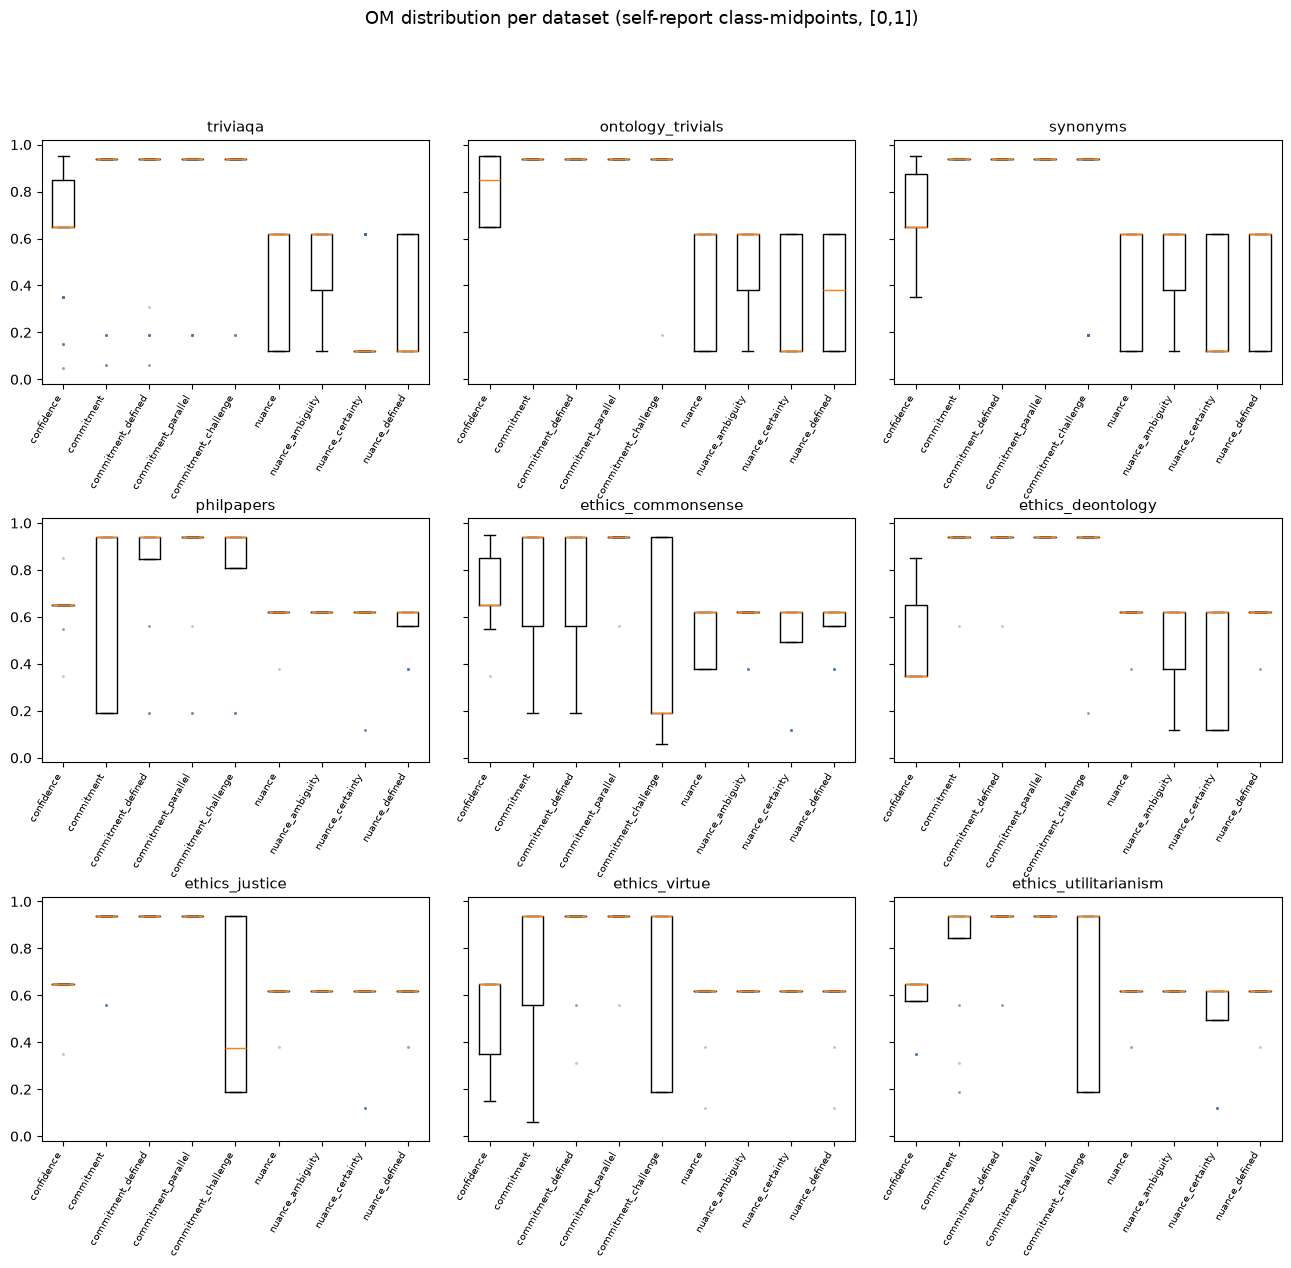

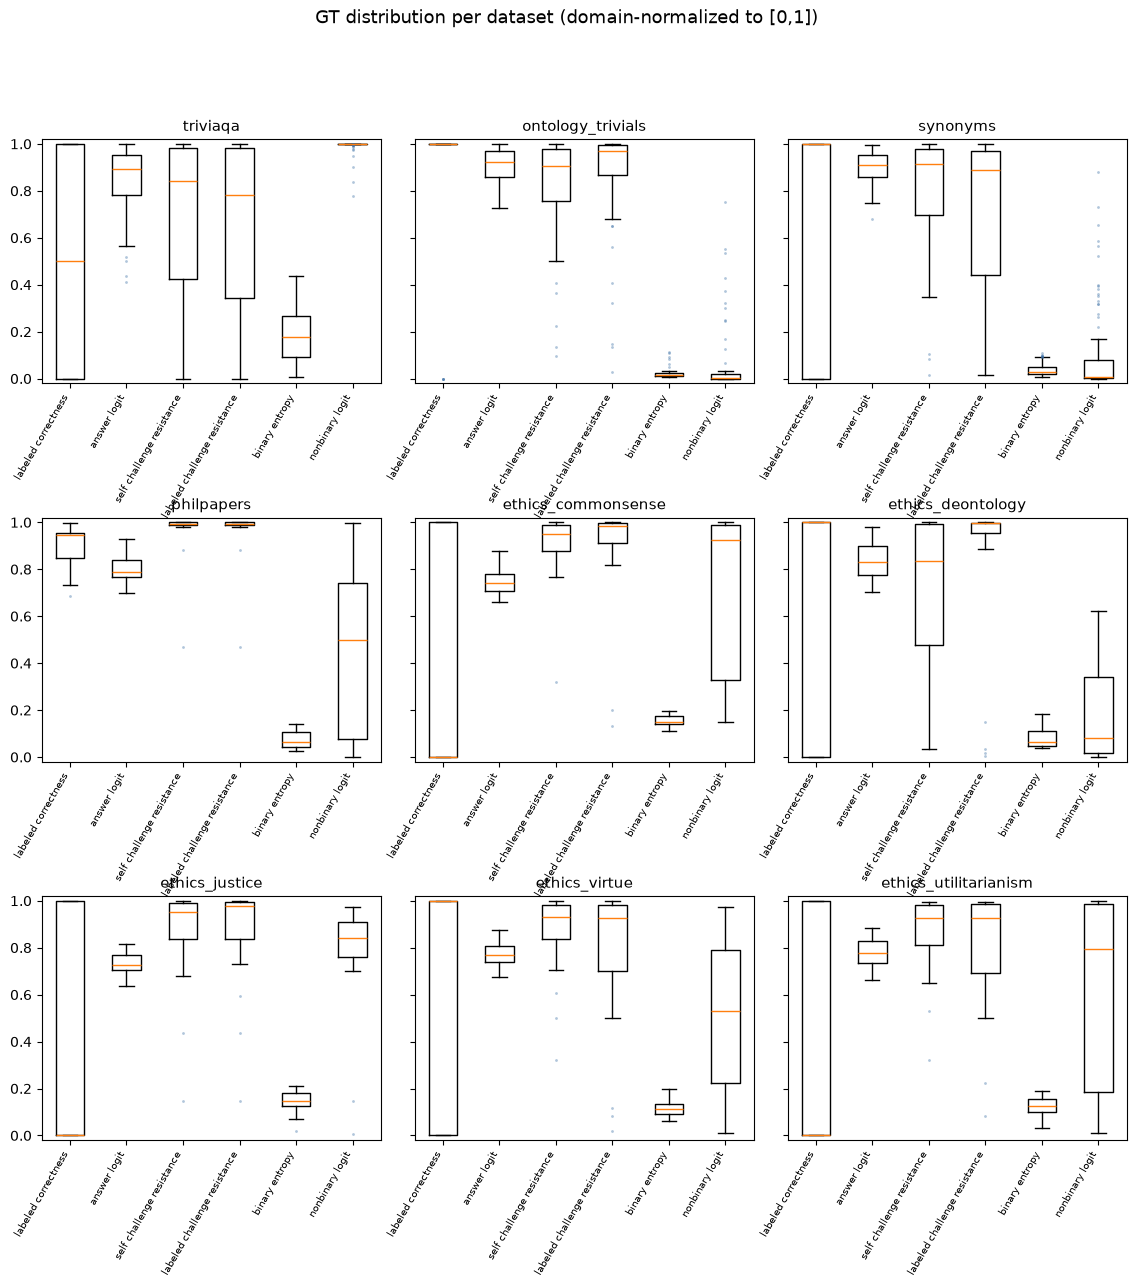

In [19]:
OM_LABELS = ["confidence", "commitment", "commitment_defined", "commitment_parallel", "commitment_challenge",
             "nuance", "nuance_ambiguity", "nuance_certainty", "nuance_defined"]
GT_LABELS = [("labeled correctness", "correctness"), ("answer logit", "logit_gt"),
             ("self challenge resistance", "gegt"), ("labeled challenge resistance", "hegt"),
             ("binary entropy", "entropy_gt"), ("nonbinary logit", "nbgt")]
FLIER_STYLE = dict(marker="o", markersize=2, alpha=0.4, markeredgecolor="none", markerfacecolor="#3b6ea5")

fig7, axes7 = plt.subplots(3, 3, figsize=(16, 13), sharey=True)
axes7 = axes7.flatten()
for idx, (ax, dataset) in enumerate(zip(axes7, construct_raw)):
    data = [np.asarray(construct_raw[dataset]["om"][om], dtype=float) for om in OM_LABELS]
    ax.boxplot(data, tick_labels=OM_LABELS, showfliers=True, flierprops=FLIER_STYLE)
    ax.set_xticklabels(OM_LABELS, rotation=60, ha="right", fontsize=7)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(axis="y", labelleft=(idx % 3 == 0))
fig7.suptitle("OM distribution per dataset (self-report class-midpoints, [0,1])", fontsize=13)
fig7.subplots_adjust(wspace=0.1, hspace=0.55)
fig7.savefig(FIGS_DIR / "om_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

fig8, axes8 = plt.subplots(3, 3, figsize=(14, 13), sharey=True)
axes8 = axes8.flatten()
gt_disp_labels = [disp for disp, _ in GT_LABELS]
for idx, (ax, dataset) in enumerate(zip(axes8, construct_raw)):
    data = [normalize_gt(key, construct_raw[dataset]["gt"][key]) for _, key in GT_LABELS]
    data = [d[~np.isnan(d)] for d in data]  # boxplot doesn't drop NaN itself -- it corrupts the whole box
    ax.boxplot(data, tick_labels=gt_disp_labels, showfliers=True, flierprops=FLIER_STYLE)
    ax.set_xticklabels(gt_disp_labels, rotation=60, ha="right", fontsize=7)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(axis="y", labelleft=(idx % 3 == 0))
fig8.suptitle("GT distribution per dataset (domain-normalized to [0,1])", fontsize=13)
fig8.subplots_adjust(wspace=0.1, hspace=0.55)
fig8.savefig(FIGS_DIR / "gt_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### OM x GT joint distribution, per dataset

Nine separate 9x6 density heatmaps, one per dataset — each saved individually to
`figs/joint_<dataset>.png` as well as shown inline below.

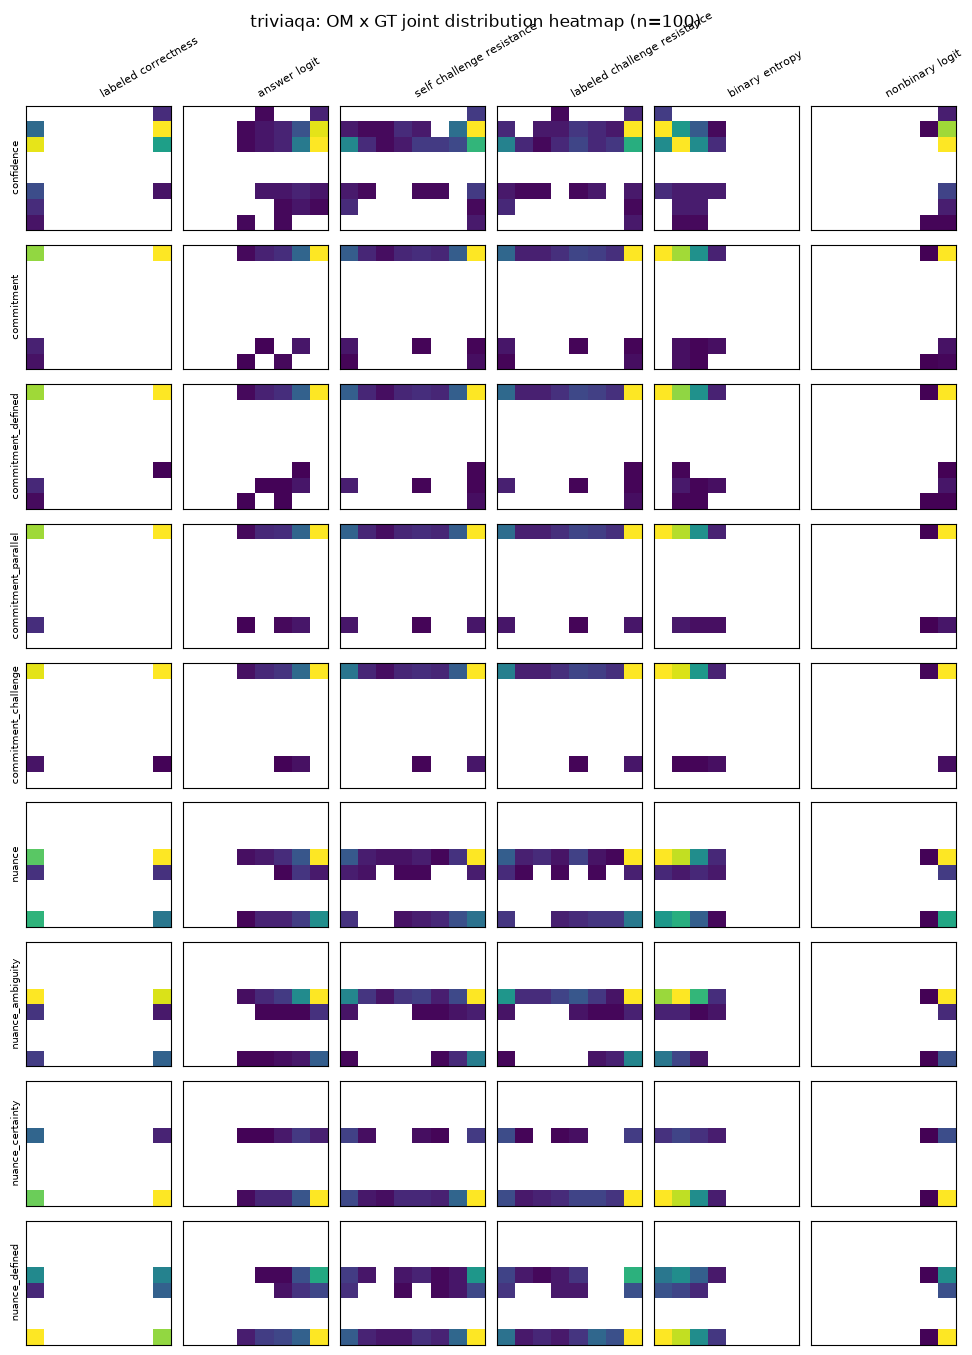

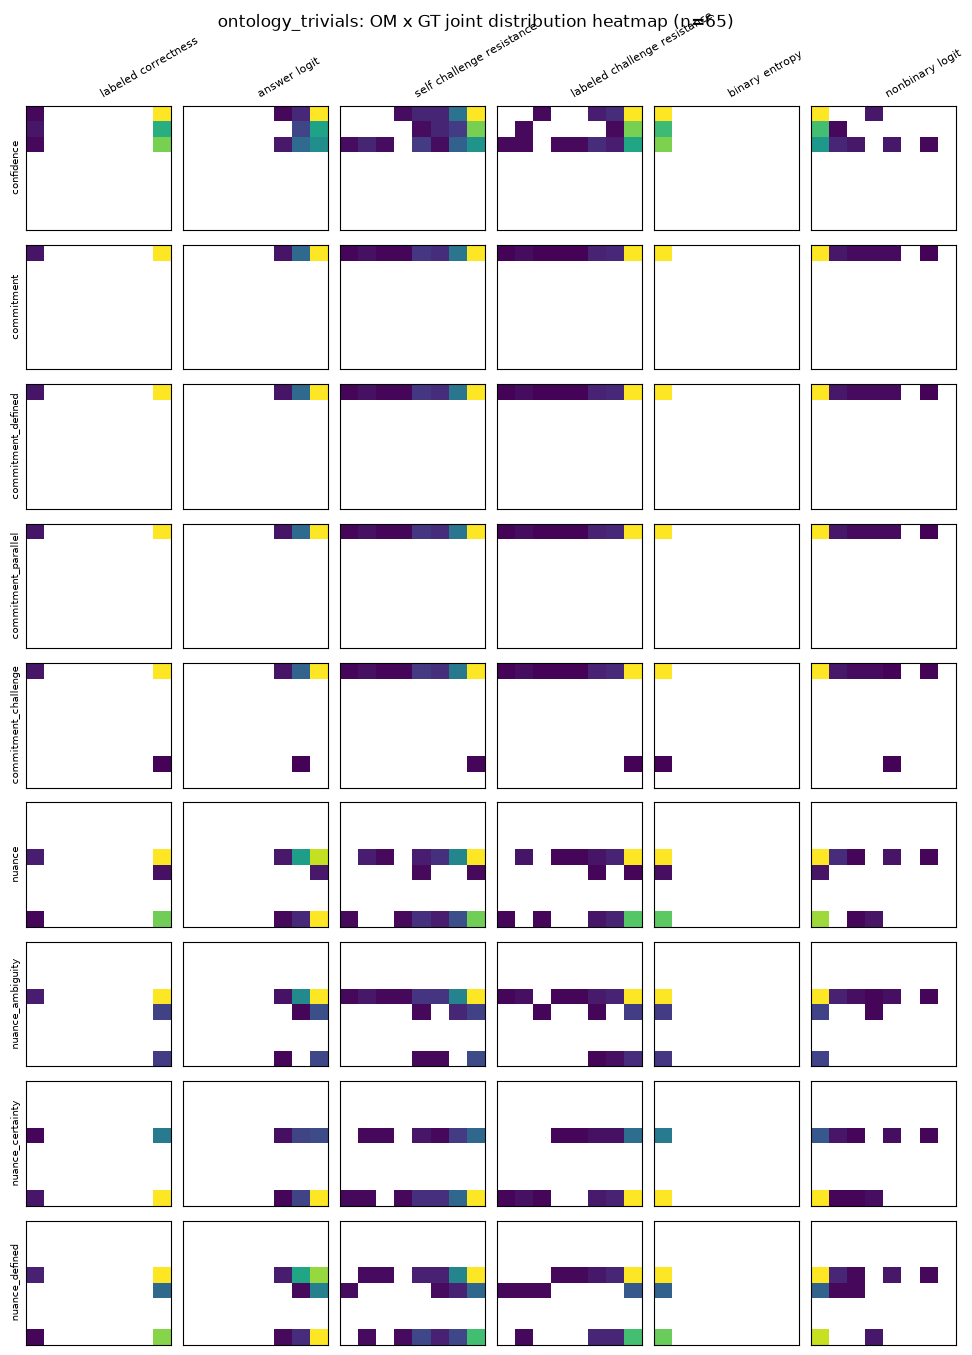

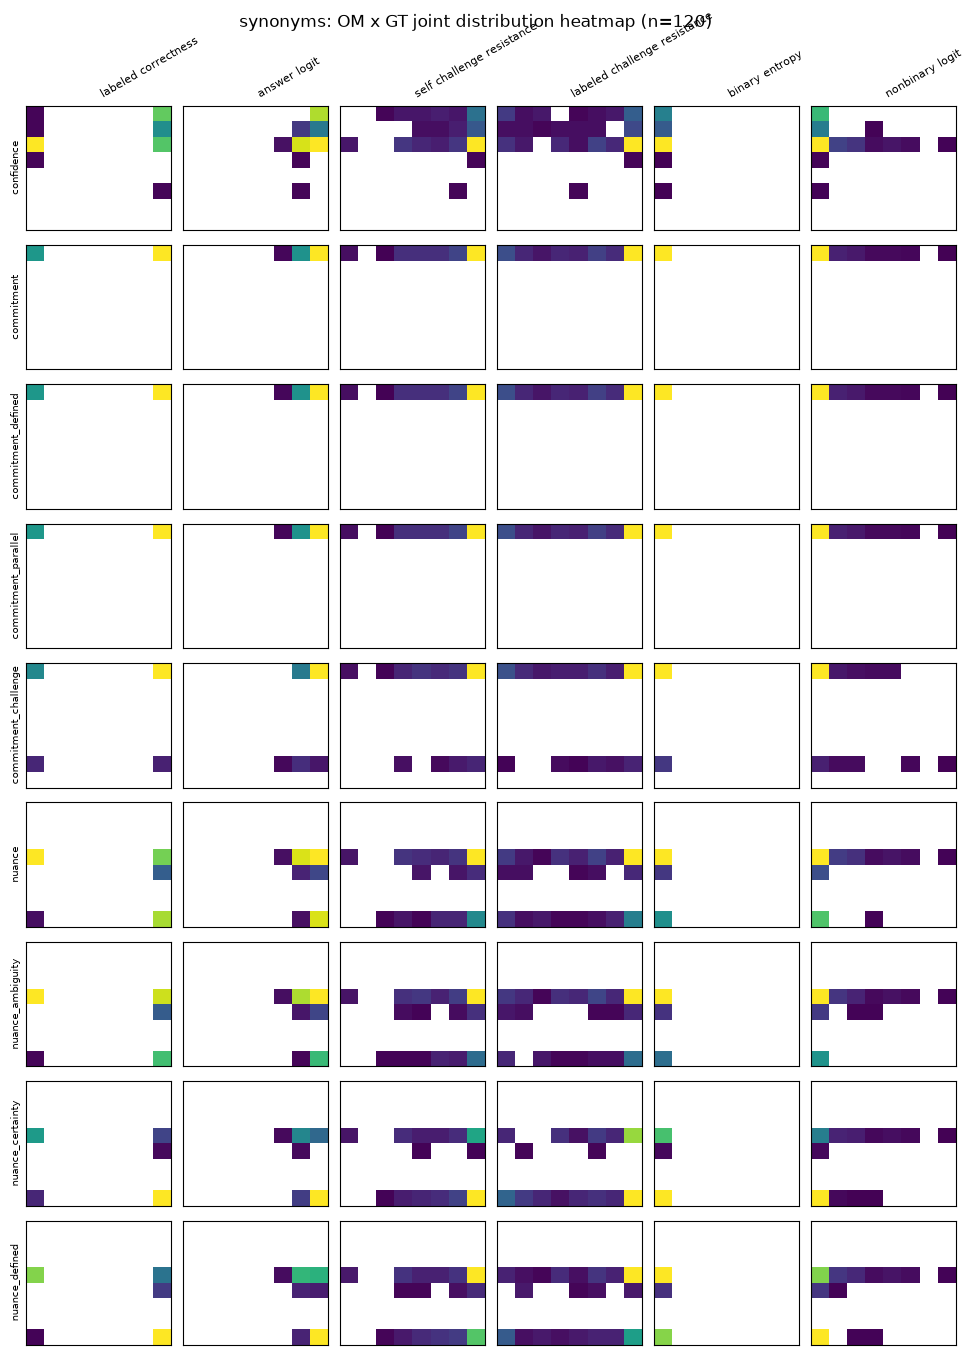

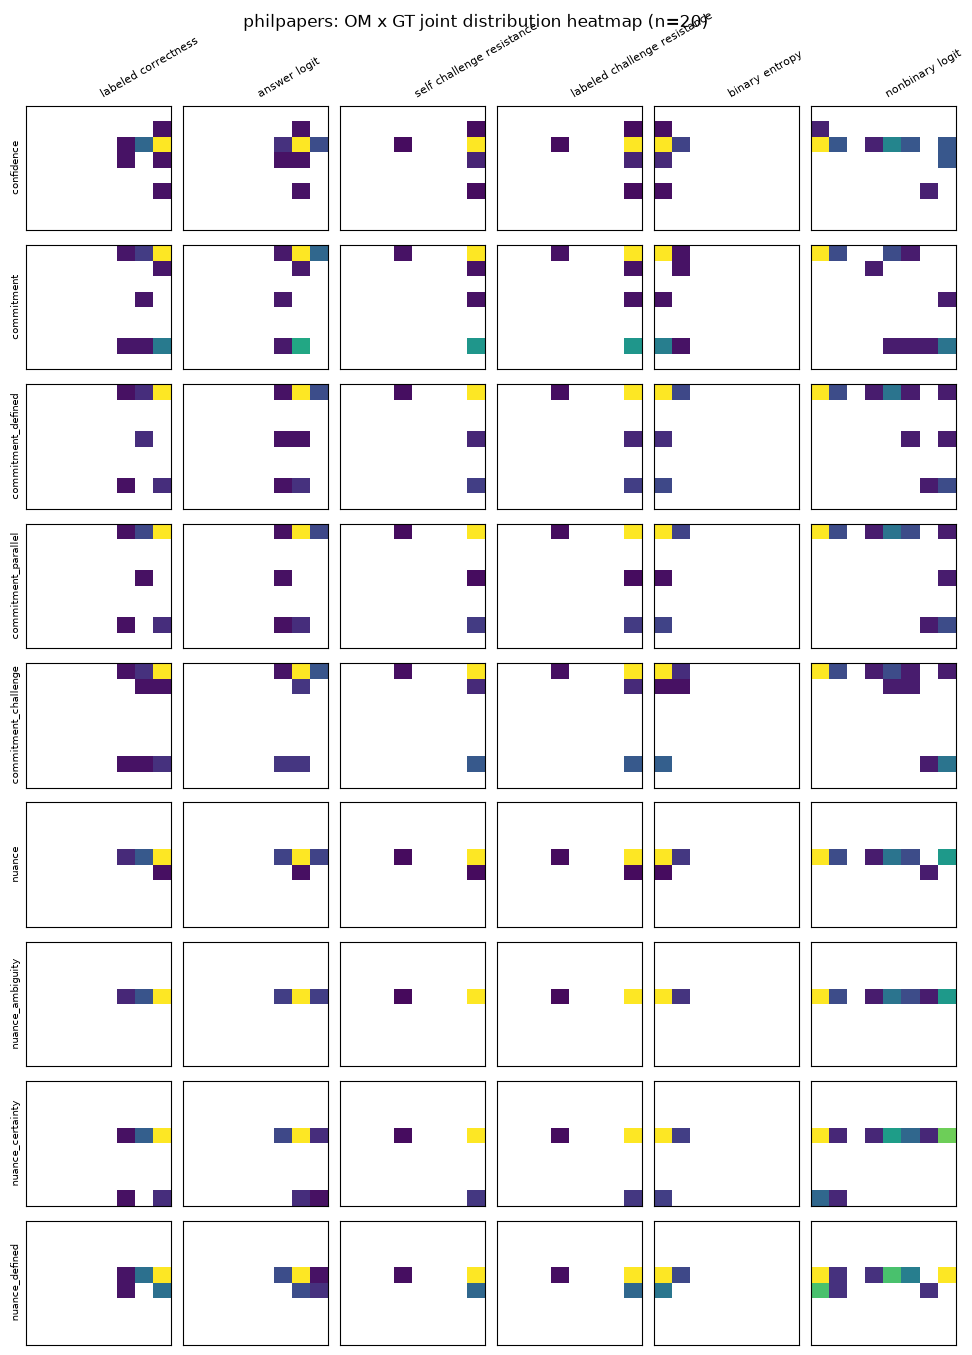

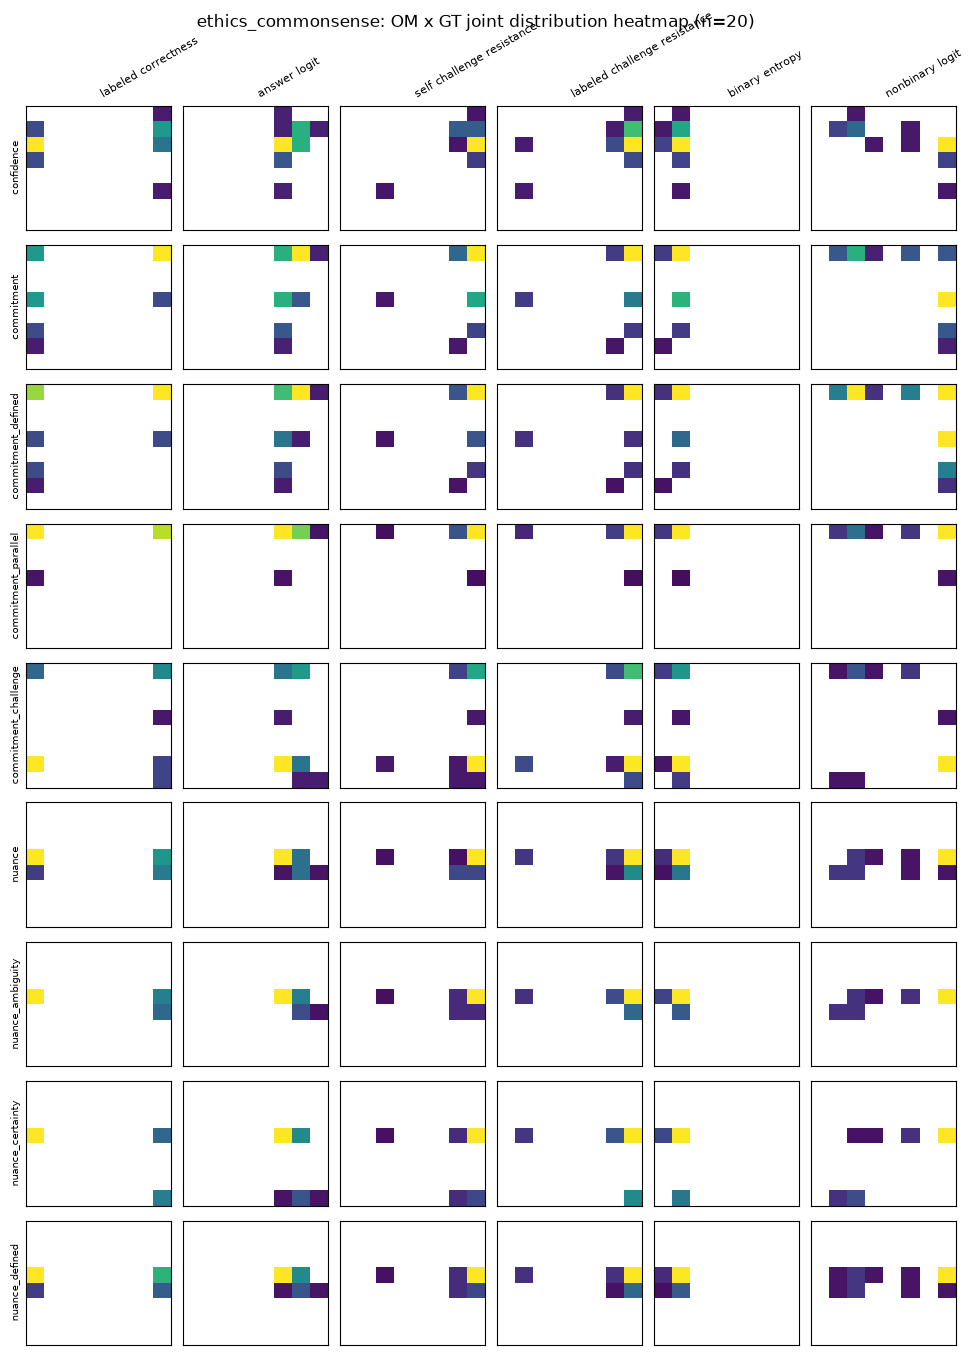

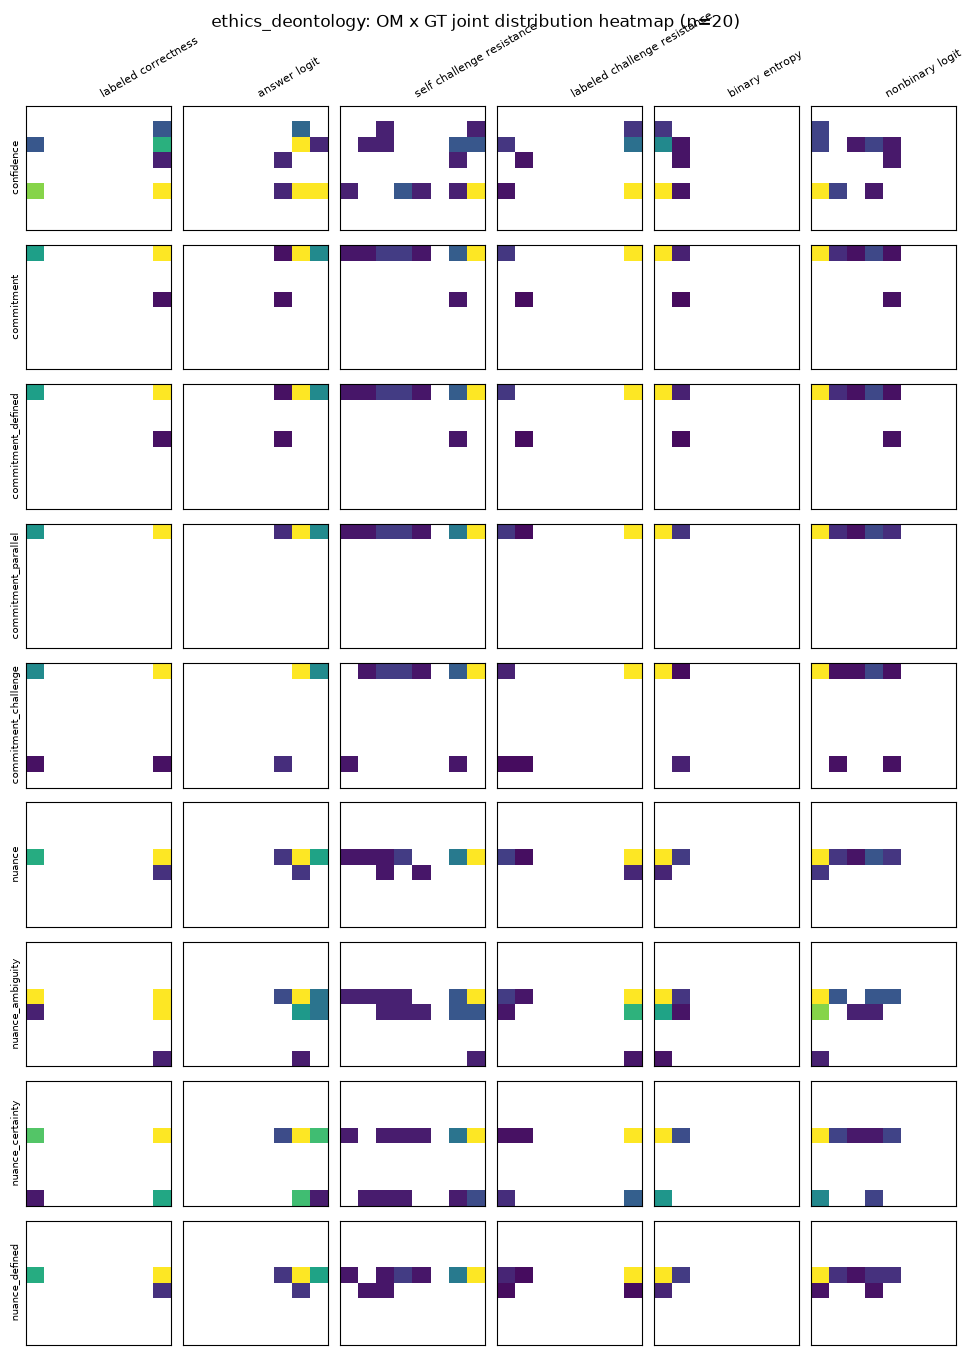

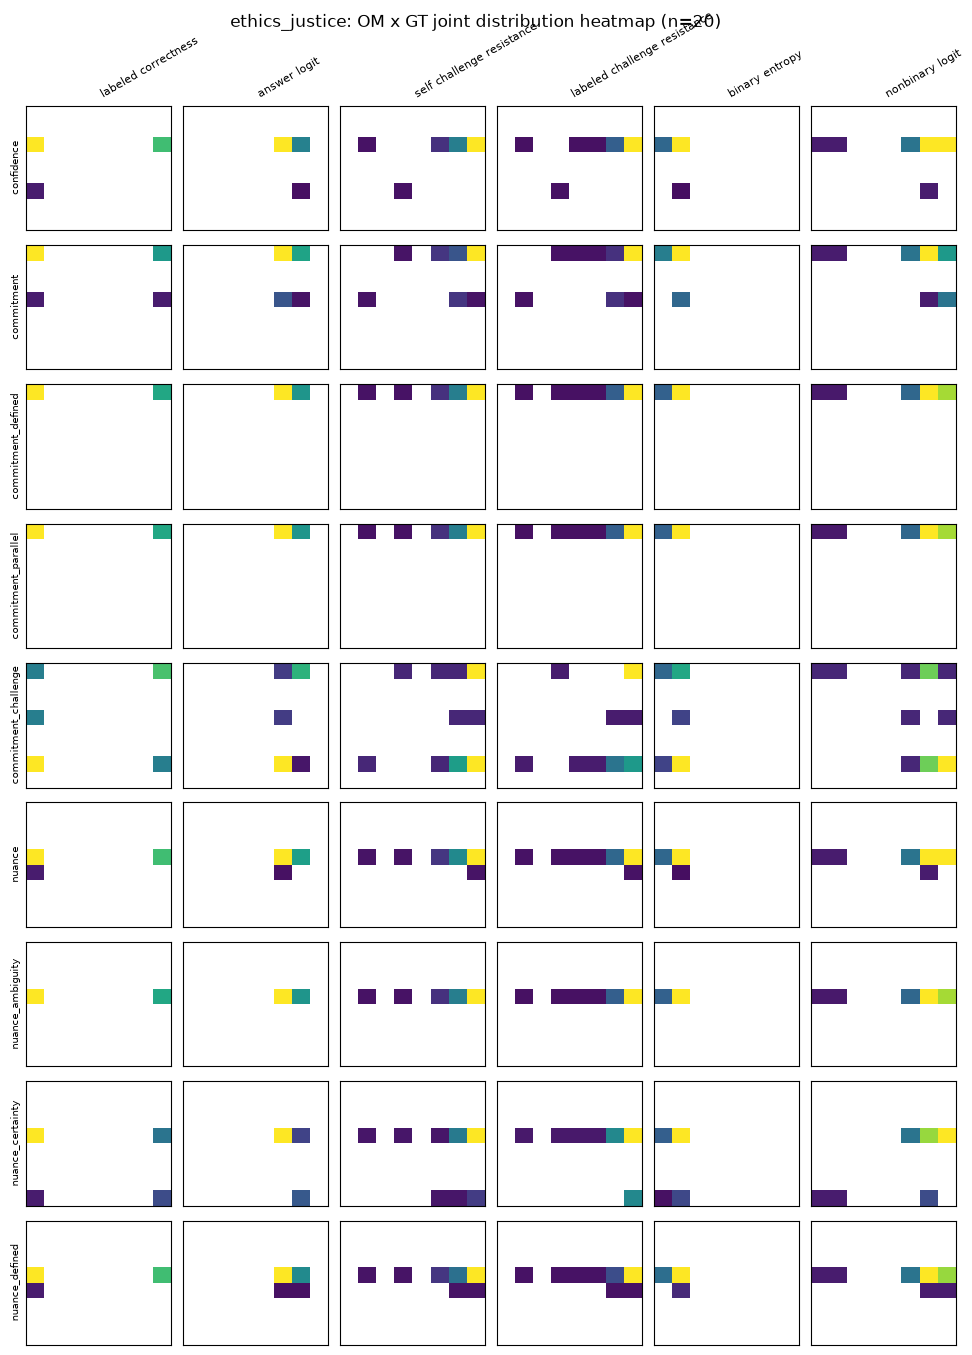

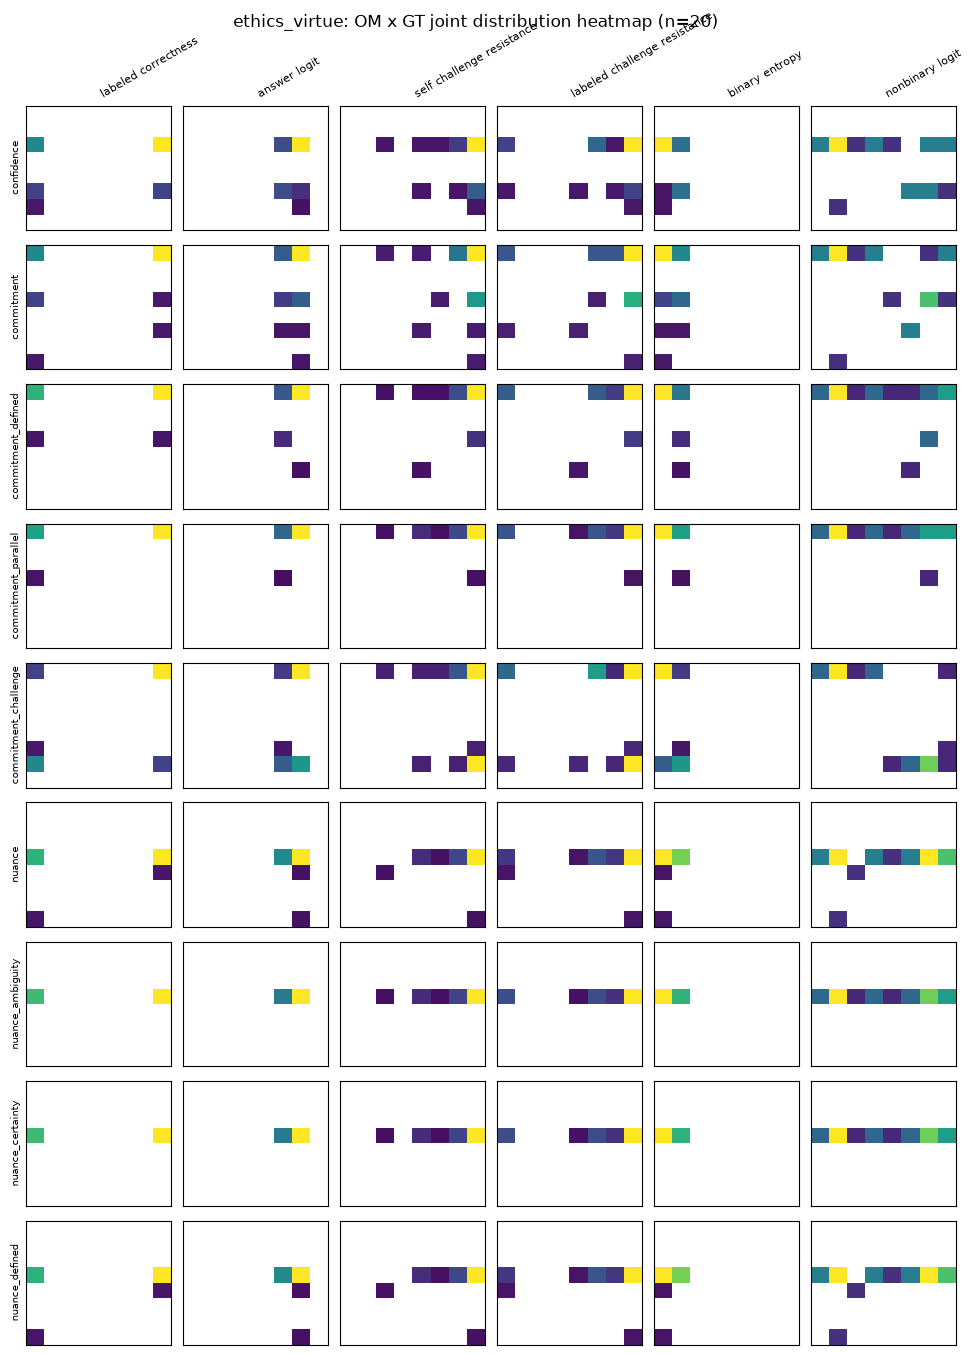

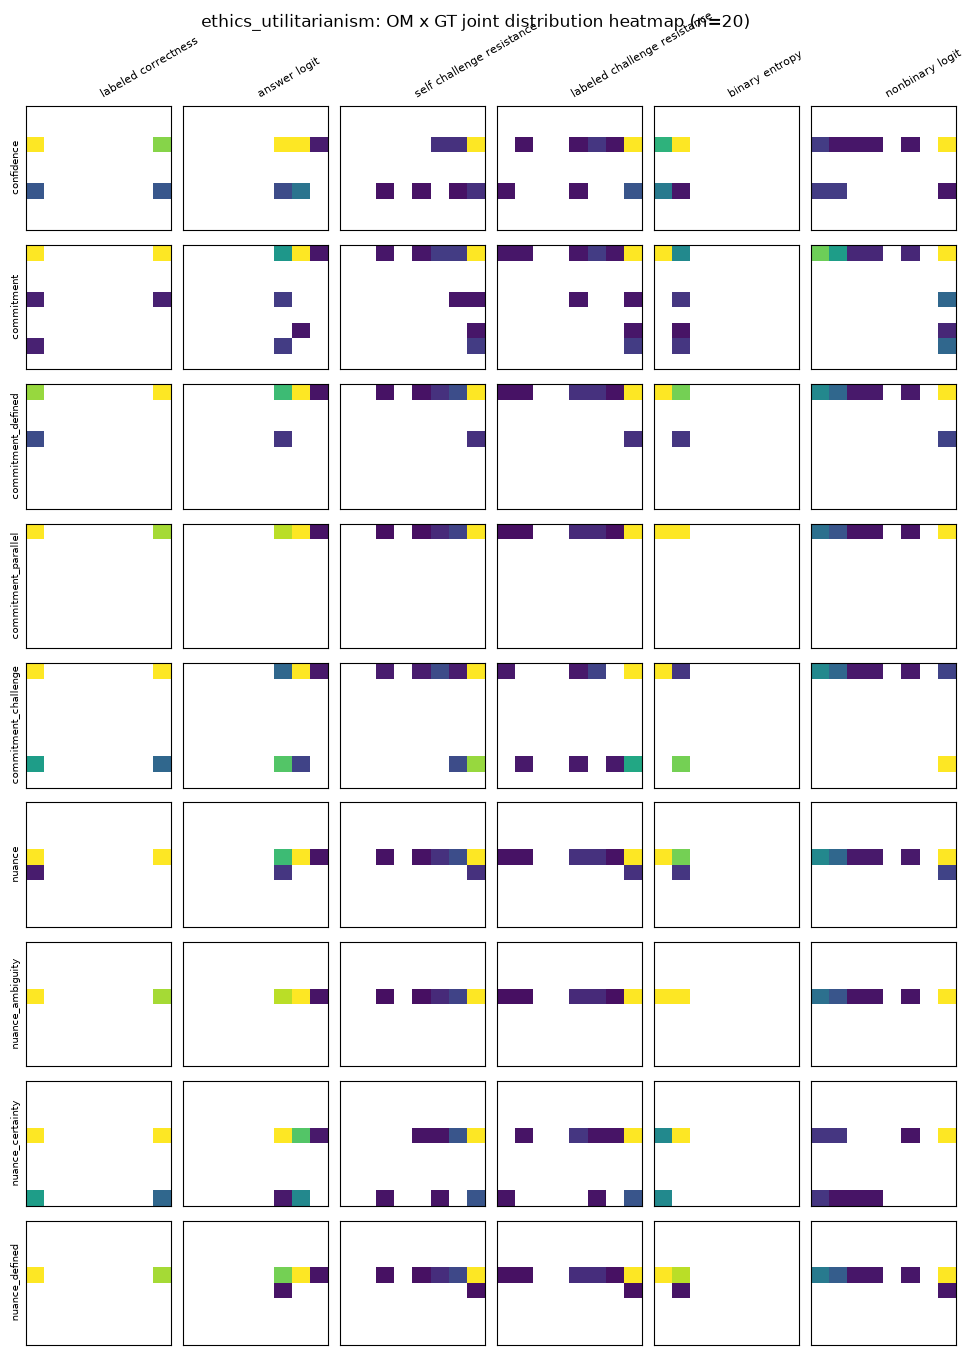

In [20]:
NBINS = 8
heat_cmap = plt.cm.viridis.copy()
heat_cmap.set_under(color="white")

for dataset in construct_raw:
    fig9, axes9 = plt.subplots(len(OM_LABELS), len(GT_LABELS), figsize=(2.0 * len(GT_LABELS), 1.7 * len(OM_LABELS)))
    for i, om in enumerate(OM_LABELS):
        om_vals = np.asarray(construct_raw[dataset]["om"][om], dtype=float)
        for j, (gt_disp, gt_key) in enumerate(GT_LABELS):
            ax = axes9[i, j]
            gt_vals = normalize_gt(gt_key, construct_raw[dataset]["gt"][gt_key])
            mask = ~(np.isnan(gt_vals) | np.isnan(om_vals))
            h, _, _ = np.histogram2d(gt_vals[mask], om_vals[mask], bins=NBINS, range=[[0, 1], [0, 1]])
            ax.imshow(h.T, origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap=heat_cmap, vmin=0.5)
            if i == 0:
                ax.set_title(gt_disp, fontsize=8, rotation=30, ha="left")
            if j == 0:
                ax.set_ylabel(om, fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
    fig9.suptitle(f"{dataset}: OM x GT joint distribution heatmap (n={construct_raw[dataset]['n']})", fontsize=12)
    fig9.subplots_adjust(wspace=0.08, hspace=0.12, top=0.92)
    fig9.savefig(FIGS_DIR / f"joint_{dataset}.png", dpi=130, bbox_inches="tight")
    plt.show()

**Interpretation.** The joint heatmaps make section 5's `NaN` cells visually obvious: a
fully-degenerate OM (e.g. `ontology_trivials`' `commitment`) is a single flat horizontal band
of density with zero vertical spread, immediately explaining why nothing can correlate with
it. `synonyms`' `commitment_challenge` row shows real bimodal structure (mass concentrated at
two distinct heights, ~0.19 and ~0.94) rather than continuous spread — worth knowing when
reading its rho, since Spearman rho on a bimodal variable answers a coarser question ("which
side of the split") than it would on a genuinely continuous one. The GT distributions confirm
`self challenge resistance`/`labeled challenge resistance` concentrate close to `1.0` for most
items on most datasets (the sigmoid-squashed margin saturates high whenever the model defends
strongly) — real variation is concentrated in a minority of items, which is exactly where
section 5's `|rho|` for those two GTs tends to be weak: most of the sample carries little
information.

## Write the model-specific conclusion report

Everything above is computed and plotted inline for interactive reading; this cell additionally renders the same tables and a manifest of this run's figures into `out/<model>/conclusion.md`, so each model's write-up is a standalone artifact next to its own `figs/` directory rather than only living in notebook cell output.

In [21]:
def df_to_md(df, float_fmt="{:.3f}"):
    cols = [str(c) for c in df.columns]
    header = "| " + " | ".join([""] + cols) + " |"
    sep = "| " + " | ".join(["---"] * (len(cols) + 1)) + " |"
    rows = []
    for idx, row in df.iterrows():
        cells = []
        for v in row:
            if isinstance(v, float):
                cells.append("NaN" if np.isnan(v) else float_fmt.format(v))
            else:
                cells.append(str(v))
        rows.append("| " + " | ".join([str(idx)] + cells) + " |")
    return "\n".join([header, sep] + rows)


def section(title, df=None, note=None):
    parts = [f"## {title}"]
    if note:
        parts.append(note)
    if df is not None:
        parts.append(df_to_md(df))
    return "\n\n".join(parts)


report = [
    f"# Phase 0 calibration -- conclusion ({MODEL_NAME})",
    f"Model: `{cfg.checkpoint}` ({cfg.n_layers} layers) -- profile `{nb.profile()}`",
    section("1. TriviaQA -- full 9x6 matrix", triviaqa_matrix, note=f"n={triviaqa_n}"),
    section("2. benzon:ontology_trivials -- full 9x6 matrix", ontology_matrix, note=f"n={ontology_n}"),
]
for name, matrix in new_matrices.items():
    report.append(section(f"New dataset: {name}", matrix, note=f"n={new_ns[name]}"))
report.append("## Construct-level 3x3, per dataset")
for dataset, m in construct_matrices.items():
    report.append(section(dataset, m))
report.append(section("Merged 9x6 matrix -- all nine datasets pooled", merged_matrix, note=f"n={total_n}"))
report.append(section(
    "Merged construct-level 3x3 -- all nine datasets pooled", merged_construct_matrix, note=f"n={total_n}",
))
report.append(section("Best OM/GT per construct -- machinewise vs. humanwise", best_df))

fig_names = sorted(p.name for p in FIGS_DIR.glob("*.png"))
report.append("## Figures")
report.append("\n".join(f"![{n}](figs/{n})" for n in fig_names))

conclusion_path = OUT_DIR / "conclusion.md"
conclusion_path.write_text("\n\n".join(report) + "\n")
print(f"wrote {conclusion_path}")

wrote /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/phase_0_calibration/out/qwen/conclusion.md
